# Behavioural Analysis for Project Defaulter Early Flagging

In [59]:
# Import all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [60]:
# Configure the output directories
plots_dir = '../plots'
files_dir = '../data/processed'
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(files_dir, exist_ok=True)

def save_plot(filename):
    os.makedirs(plots_dir, exist_ok=True)

    full_path = os.path.join(plots_dir, filename)
    plt.savefig(full_path, bbox_inches='tight', dpi=300)
    print(f"{filename} saved to: {full_path}")


def save_csv(frame, filename):
    os.makedirs(files_dir, exist_ok=True)

    full_path = os.path.join(files_dir, filename)
    frame.to_csv(full_path, index=False)
    print(f"{filename} saved to: {full_path}")

In [61]:
# Load the dataset (low_memory=false, since it was reading a columntype wrong in an attempt without it.)
dft = pd.read_csv('../data/processed/transactions.csv', low_memory=False)
dfl = pd.read_csv('../data/processed/loans.csv', low_memory=False)

In [62]:
# Configuring datetime values
dft['date'] = pd.to_datetime(dft['date'])
dfl['start_date'] = pd.to_datetime(dfl['start_date'])
dfl['end_date'] = pd.to_datetime(dfl['end_date'])

defaulter
0    606
1     76
Name: count, dtype: int64
defaulter
0    88.856305
1    11.143695
Name: proportion, dtype: float64
class_imbalance.png saved to: ../plots\class_imbalance.png


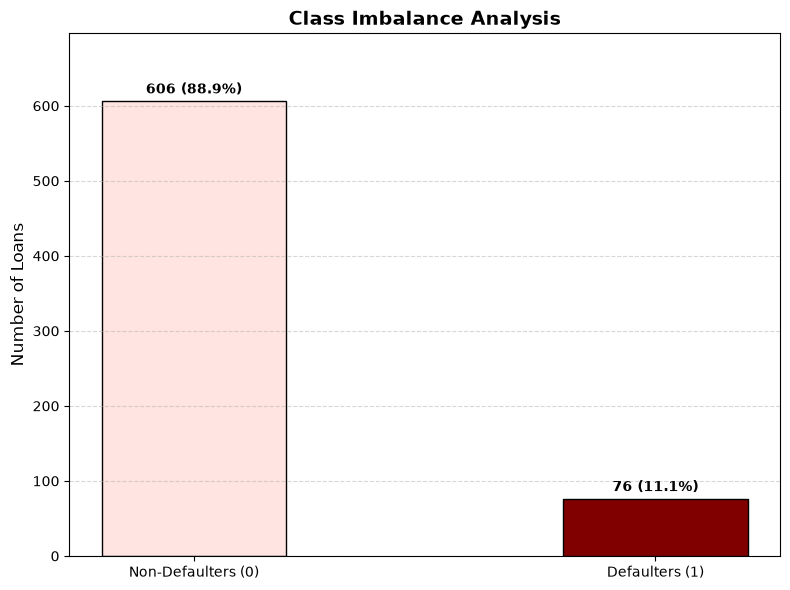

In [63]:
# State the class imbalance
print(dfl['defaulter'].value_counts())
print(dfl['defaulter'].value_counts(normalize=True) * 100)
counts = dfl["defaulter"].value_counts()
percentages = dfl["defaulter"].value_counts(normalize=True) * 100
labels = ["Non-Defaulters (0)", "Defaulters (1)"]
values = [counts.get(0, 0), counts.get(1, 0)]
pct_values = [percentages.get(0, 0), percentages.get(1, 0)]
plt.figure(figsize=(8, 6))
bars = plt.bar(
    labels,
    values,
    color=["mistyrose", "maroon"],
    edgecolor="black",
    width=0.4,
)
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + (max(values) * 0.01),
        f"{int(height):,} ({pct_values[i]:.1f}%)",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=10,
    )
plt.title(
    "Class Imbalance Analysis",
    fontsize=14,
    fontweight="bold",
)
plt.ylabel("Number of Loans", fontsize=12)
plt.ylim(0, max(values) * 1.15)
plt.grid(axis="y", linestyle="--", alpha=0.5)
save_plot('class_imbalance.png')
plt.tight_layout()
plt.show()

> ##### *A significant class imbalance, but resembling the real-world scenerio. Must be stated before any analysis.*

loans_per_account.png saved to: ../plots\loans_per_account.png


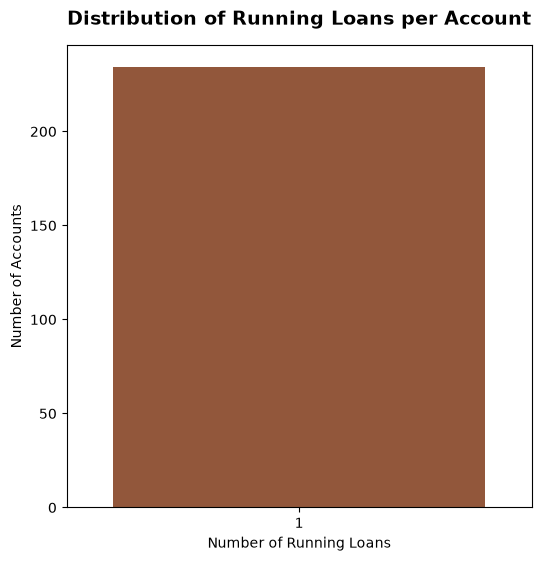

In [64]:
# Find the number of Loans per account
dfl_running = dfl[dfl['running'] == 1]
loan_count = (
    dfl_running.groupby('account_id').size().reset_index(name='running_loan_count')
)
plt.figure(figsize=(6,6))

sns.countplot(
    data=loan_count,
    x='running_loan_count',
    color='sienna'
)

plt.title('Distribution of Running Loans per Account', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Number of Running Loans')
plt.ylabel('Number of Accounts')
plt.xticks(rotation=0)
save_plot('loans_per_account.png')
plt.show()

> ##### *Confirmed that no account has more than one running loan.*

duration_vs_default.png saved to: ../plots\duration_vs_default.png


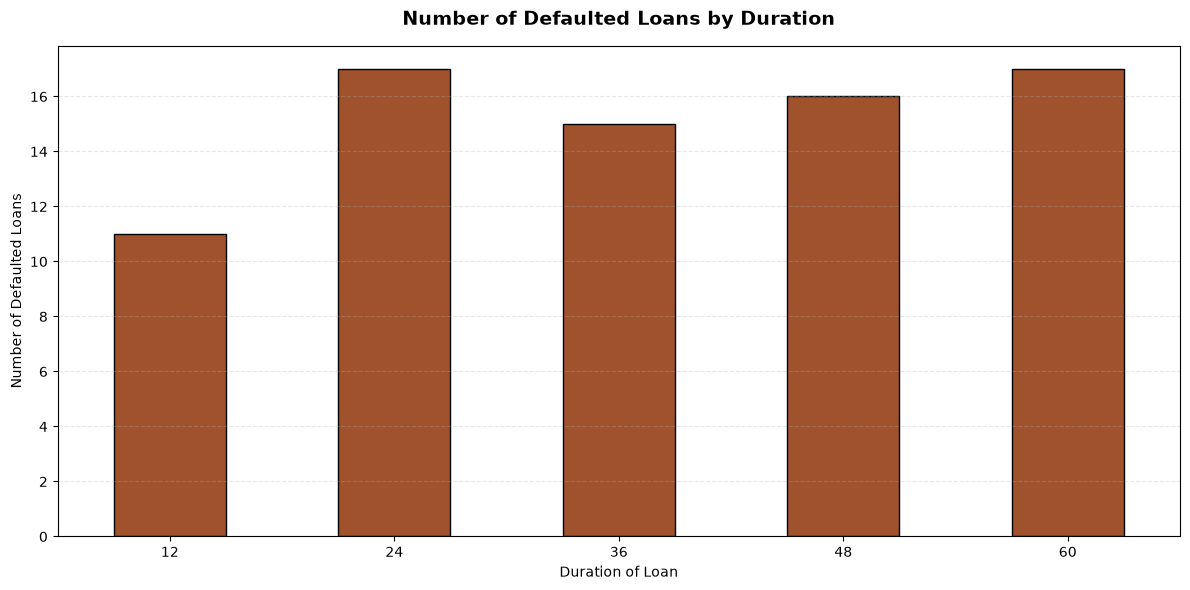

In [65]:
# Bivariate relationship between number of default loans and loan duration
plt.figure(figsize=(12,6))
defaulted_dfl = dfl[dfl['defaulter'] == 1]
duration_counts = defaulted_dfl['duration'].value_counts().sort_index()
duration_counts.plot(kind='bar', color='sienna', edgecolor='black')

plt.title('Number of Defaulted Loans by Duration', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Duration of Loan')
plt.ylabel('Number of Defaulted Loans')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
save_plot('duration_vs_default.png')
plt.show()

> ##### *No specific pattern observed. Duration of loan holds very less weight in deciding whether it'll be defaulted or not.*

amount_vs_default.png saved to: ../plots\amount_vs_default.png


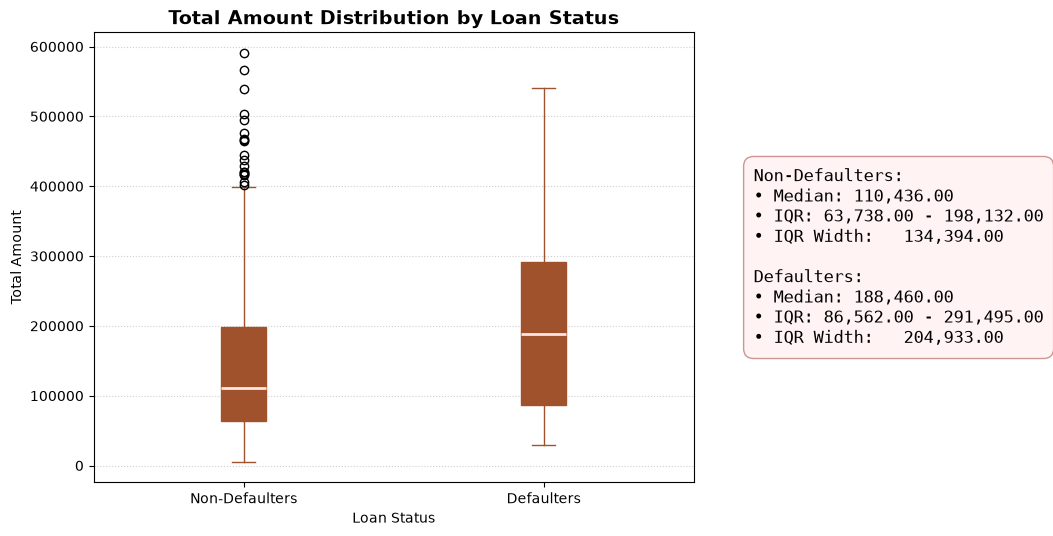

In [66]:
# Lend amount distribution among loan defaulters and non-defaulters
summary = dfl.groupby('defaulter')['total_amount'].describe()
iqr_0 = summary.loc[0, '75%'] - summary.loc[0, '25%']
iqr_1 = summary.loc[1, '75%'] - summary.loc[1, '25%']

insights_text = (
    'Non-Defaulters:\n'
    f'• Median: {summary.loc[0, '50%']:,.2f}\n'
    f'• IQR: {summary.loc[0, '25%']:,.2f} - {summary.loc[0, '75%']:,.2f}\n'
    f'• IQR Width:   {iqr_0:,.2f}\n\n'
    'Defaulters:\n'
    f'• Median: {summary.loc[1, '50%']:,.2f}\n'
    f'• IQR: {summary.loc[1, '25%']:,.2f} - {summary.loc[1, '75%']:,.2f}\n'
    f'• IQR Width:   {iqr_1:,.2f}'
)

fig, ax = plt.subplots(figsize=(12, 6))

dfl.boxplot(column='total_amount', by='defaulter', grid=False, patch_artist=True, 
            color='sienna', medianprops={'color': 'mistyrose', 'linewidth': 2}, ax=ax)

plt.title('Total Amount Distribution by Loan Status', fontsize=14, fontweight='bold')
plt.suptitle('')
plt.xlabel('Loan Status')
plt.ylabel('Total Amount')
plt.xticks([1, 2], ['Non-Defaulters', 'Defaulters'])
plt.grid(axis='y', linestyle=':', alpha=0.6)

box_style = dict(boxstyle='round,pad=0.6', facecolor='mistyrose', edgecolor='maroon', alpha=0.4)
ax.text(1.1, 0.5, insights_text, transform=ax.transAxes, fontsize=12, fontfamily='monospace',
        verticalalignment='center', horizontalalignment='left', bbox=box_style)
plt.subplots_adjust(right=0.60, left=0.1, bottom=0.15, top=0.9)
save_plot('amount_vs_default.png')
plt.show()

> ##### *Interesting insights here. Even though the higher amount loans, >$200000, are likely to default, the outliers in non-defaulters contradict this point. Final conclusion is that the amount of loan doesn't affect that fact that loan may get defaulted.*

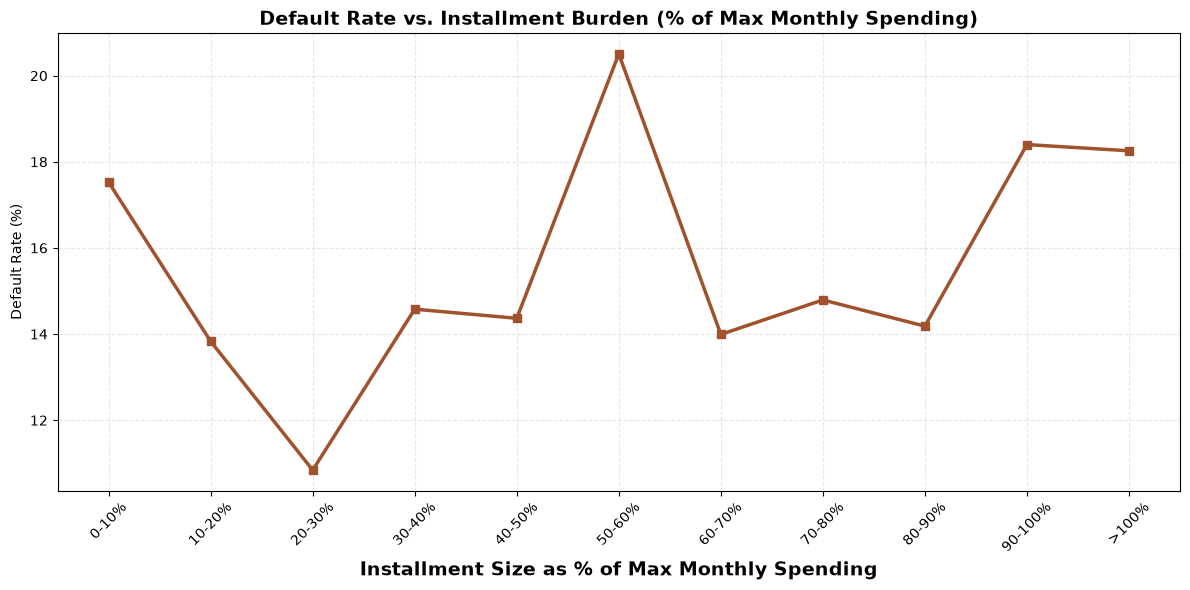

In [67]:
# Bivariate relation between default rate and installment as the percentage of maximum monthly spending
dft['month_year'] = dft['date'].dt.to_period('M')
spending_df = dft[dft['type'].str.lower().str.contains('withdrawal|out', na=False)]

max_spending = (
    spending_df.groupby(['account_id', 'month_year'])['amount']
    .max()
    .reset_index()
)
max_spending.rename(columns={'amount': 'max_spending_month'}, inplace=True)
merged_df = pd.merge(max_spending, dfl, on='account_id', how='inner')

merged_df['installment_pct'] = (
    merged_df['installment'] / merged_df['max_spending_month']
) * 100

bins = list(range(0, 110, 10)) + [float('inf')]
labels = [f'{i}-{i+10}%' for i in range(0, 100, 10)] + ['>100%']
merged_df['pct_bin'] = pd.cut(
    merged_df['installment_pct'], bins=bins, labels=labels
)

default_rate_by_pct = merged_df.groupby('pct_bin', observed=True)['defaulter'].mean() * 100

plt.figure(figsize=(12, 6))
plt.plot(
    default_rate_by_pct.index.astype(str),
    default_rate_by_pct.values,
    marker='s',
    linestyle='-',
    color='sienna',
    linewidth=2.5,
)
plt.title(
    'Default Rate vs. Installment Burden (% of Max Monthly Spending)',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Installment Size as % of Max Monthly Spending', fontsize=14, fontweight='bold')
plt.ylabel('Default Rate (%)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> ##### *No specific pattern observed. The default rate between 5% and 20%. Not much of a difference. No useful insights here. Change the denominator to Average monthly credits.*

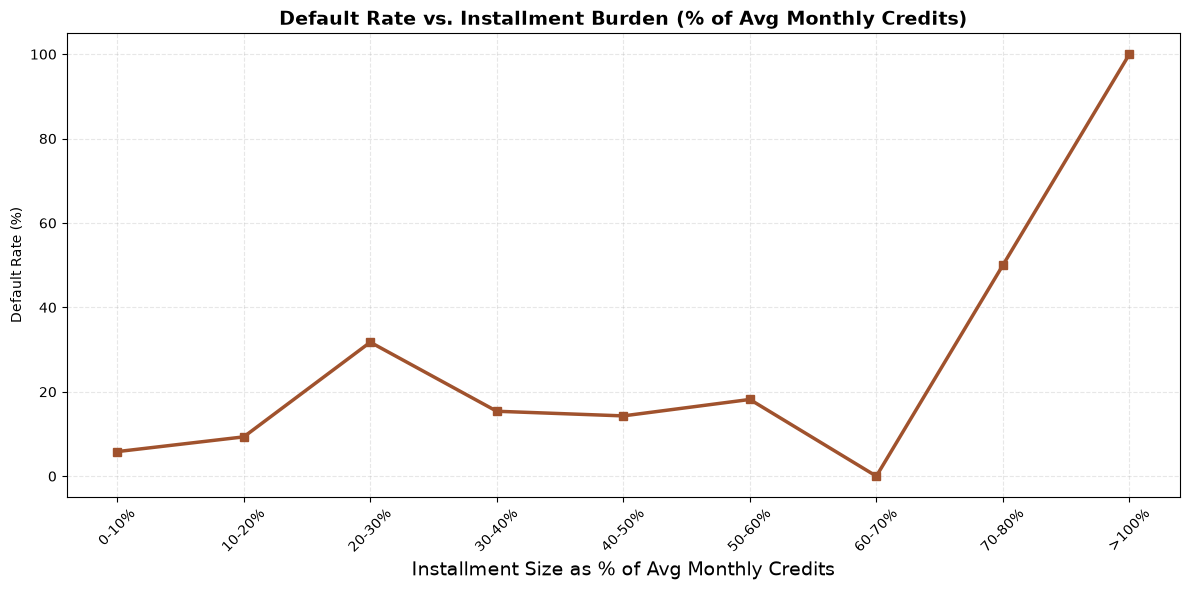

In [68]:
# Bivariate relation between default rate and installment as the percentage of average monthly credits
spending_df = dft[dft['type'].str.lower().str.contains('credit', na=False)]

avg_credits = (
    spending_df.groupby(['account_id', 'month_year'])['amount']
    .sum()
    .reset_index()
    .groupby('account_id')['amount']
    .mean()
    .reset_index()
)
avg_credits.rename(columns={'amount': 'avg_monthly_credits'}, inplace=True)
merged_df = pd.merge(avg_credits, dfl, on='account_id', how='inner')

merged_df['installment_pct'] = (
    merged_df['installment'] / merged_df['avg_monthly_credits']
) * 100

bins = list(range(0, 110, 10)) + [float('inf')]
labels = [f'{i}-{i+10}%' for i in range(0, 100, 10)] + ['>100%']
merged_df['pct_bin'] = pd.cut(
    merged_df['installment_pct'], bins=bins, labels=labels
)

default_rate_by_pct = merged_df.groupby('pct_bin', observed=True)['defaulter'].mean() * 100

plt.figure(figsize=(12, 6))
plt.plot(
    default_rate_by_pct.index.astype(str),
    default_rate_by_pct.values,
    marker='s',
    linestyle='-',
    color='sienna',
    linewidth=2.5,
)
plt.title(
    'Default Rate vs. Installment Burden (% of Avg Monthly Credits)',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Installment Size as % of Avg Monthly Credits', fontsize=14)
plt.ylabel('Default Rate (%)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> ##### *A serious question is raised for the 70-80% and >100% bucket. How did the bank approve a loan whose monthly installment exceeds a person's monthly income? Either the data has flaws or the data in those specific buckets is not in a valuable scale.*

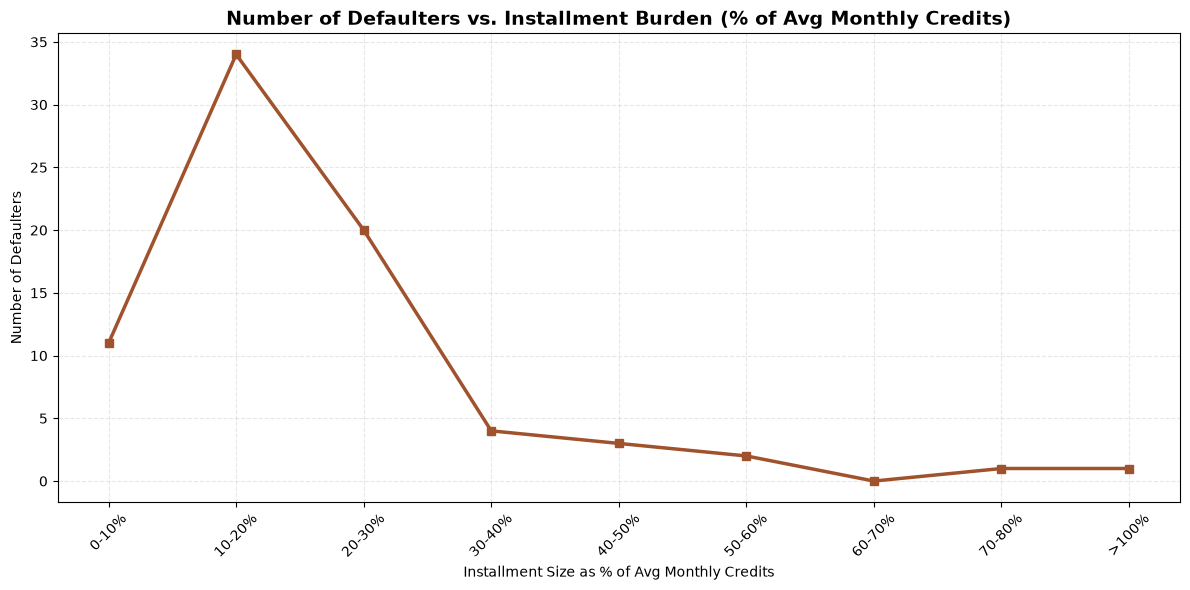

In [69]:
# Bivariate relation between number of defaulters and installment as the percentage of average monthly credits
spending_df = dft[dft['type'].str.lower().str.strip().isin(['deposit', 'in', 'incoming', 'credit'])]

avg_credits = (
    spending_df.groupby(['account_id', 'month_year'])['amount']
    .sum()
    .reset_index()
    .groupby('account_id')['amount']
    .mean()
    .reset_index()
)
avg_credits.rename(columns={'amount': 'avg_monthly_credits'}, inplace=True)
merged_df = pd.merge(avg_credits, dfl, on='account_id', how='inner')

merged_df['installment_pct'] = (
    merged_df['installment'] / merged_df['avg_monthly_credits']
) * 100

bins = list(range(0, 110, 10)) + [float('inf')]
labels = [f'{i}-{i+10}%' for i in range(0, 100, 10)] + ['>100%']
merged_df['pct_bin'] = pd.cut(
    merged_df['installment_pct'], bins=bins, labels=labels
)
defaulter_counts_by_pct = merged_df.groupby('pct_bin', observed=True)['defaulter'].sum()

plt.figure(figsize=(12, 6))
plt.plot(
    defaulter_counts_by_pct.index.astype(str),
    defaulter_counts_by_pct.values,
    marker='s',
    linestyle='-',
    color='sienna',
    linewidth=2.5,
)
plt.title(
    'Number of Defaulters vs. Installment Burden (% of Avg Monthly Credits)',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Installment Size as % of Avg Monthly Credits')
plt.ylabel('Number of Defaulters')
plt.grid(True, linestyle='--', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> ##### *Yep, the data is too less to gain valuable insights. There are only 4 of such accounts in the last two buckets. But still, no useful conclusions as there's a dip just after 10-20% bucket. Concluding that this metric is not reliable for this data.*

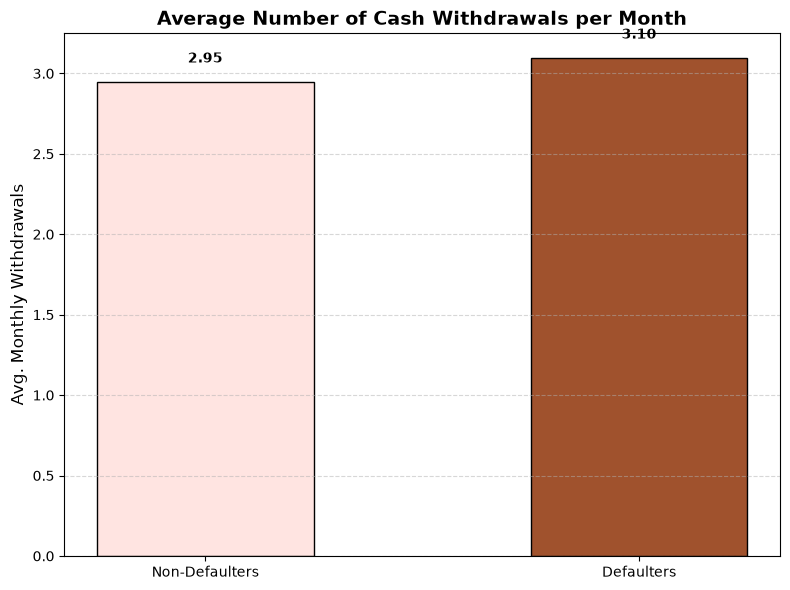

In [70]:
# Plot average monthly cash withdrawals vs defaults
dft['month_year'] = dft['date'].dt.to_period('M')
cash_df = dft[
    dft['operation'].str.lower().str.contains('cash withdrawal', na=False)
]
withdrawal_counts = (
    cash_df.groupby(['account_id', 'month_year']).size().reset_index(name='count')
)
avg_monthly_withdrawals = (
    withdrawal_counts.groupby('account_id')['count'].mean().reset_index()
)
avg_monthly_withdrawals.rename(
    columns={'count': 'avg_withdrawals_per_month'}, inplace=True
)
merged_df = pd.merge(avg_monthly_withdrawals, dfl, on='account_id', how='inner')
summary_stats = merged_df.groupby('defaulter')[
    'avg_withdrawals_per_month'
].mean()

plt.figure(figsize=(8, 6))
bars = plt.bar(
    ['Non-Defaulters', 'Defaulters'],
    summary_stats.values,
    color=['mistyrose', 'sienna'],
    edgecolor='black',
    width=0.5,
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.1,
        f'{yval:.2f}',
        ha='center',
        va='bottom',
        fontweight='bold',
    )
plt.title(
    'Average Number of Cash Withdrawals per Month',
    fontsize=14,
    fontweight='bold',
)
plt.ylabel('Avg. Monthly Withdrawals', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

> ##### *No specific insight here too. Both values are almost the same.*

avg_monthly_balance_trend.png saved to: ../plots\avg_monthly_balance_trend.png


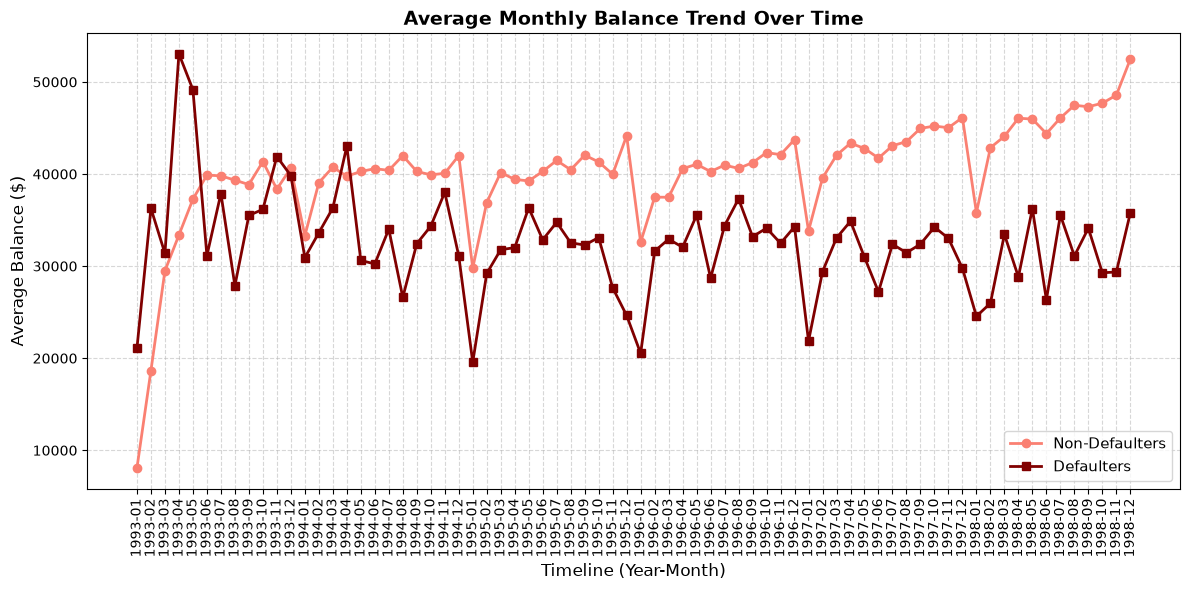

In [71]:
# Average monthly balance over time separated for both defaulters and non-defaulters

dft['month_year'] = dft['date'].dt.to_period('M')
monthly_closing = (
    dft.sort_values(by=['account_id', 'date', 'trans_id'])
    .groupby(['account_id', 'month_year'])['balance']
    .last()
    .reset_index()
)
merged_timeline = pd.merge(monthly_closing, dfl, on='account_id', how='inner')

timeline_stats = (
    merged_timeline.groupby(['month_year', 'defaulter'])['balance']
    .mean()
    .unstack()
)
timeline_stats.index = timeline_stats.index.astype(str)

plt.figure(figsize=(12, 6))
plt.plot(
    timeline_stats.index,
    timeline_stats[0],
    marker='o',
    color='salmon',
    linewidth=2,
    label='Non-Defaulters',
)
plt.plot(
    timeline_stats.index,
    timeline_stats[1],
    marker='s',
    color='maroon',
    linewidth=2,
    label='Defaulters',
)
plt.title(
    'Average Monthly Balance Trend Over Time', fontsize=14, fontweight='bold'
)
plt.xlabel('Timeline (Year-Month)', fontsize=12)
plt.ylabel('Average Balance ($)', fontsize=12)
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
save_plot('avg_monthly_balance_trend.png')
plt.tight_layout()
plt.show()

##### *Very useful insight. Defaulters' account balances are swinging around the same horizontal line, while the Non-Defaulters' increase gradually. And it is almost always more than Defaulters'. Conclusion is the non-defaulters accumulate wealth overtime, while defaulters spend as much money almost as they earn.*

median_monthly_balance_trend.png saved to: ../plots\median_monthly_balance_trend.png


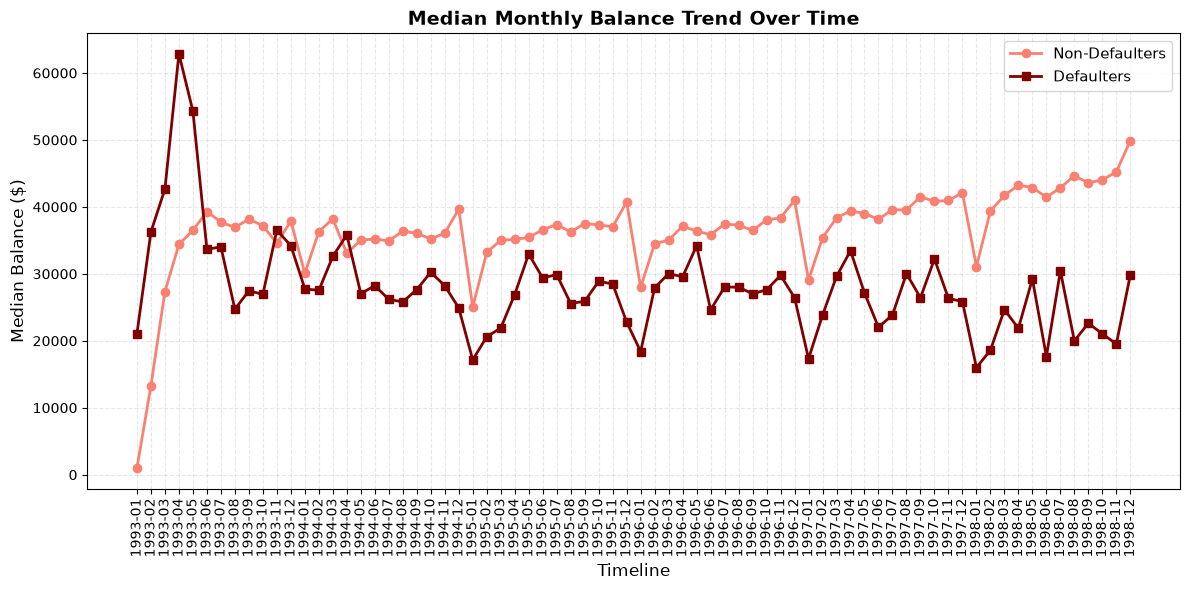

In [72]:
# Median monthly balance over time separated for both defaulters and non-defaulters

dft['month_year'] = dft['date'].dt.to_period('M')

monthly_closing = (
    dft.sort_values(by=['account_id', 'date', 'trans_id'])
    .groupby(['account_id', 'month_year'])['balance']
    .last()
    .reset_index()
)

merged_timeline = pd.merge(monthly_closing, dfl, on='account_id', how='inner')

timeline_medians = (
    merged_timeline.groupby(['month_year', 'defaulter'])['balance']
    .median()
    .unstack()
)
timeline_medians.index = timeline_medians.index.astype(str)

plt.figure(figsize=(12, 6))
plt.plot(
    timeline_medians.index,
    timeline_medians[0],
    marker='o',
    color='salmon',
    linewidth=2,
    label='Non-Defaulters',
)
plt.plot(
    timeline_medians.index,
    timeline_medians[1],
    marker='s',
    color='maroon',
    linewidth=2,
    label='Defaulters',
)
plt.title(
    'Median Monthly Balance Trend Over Time', fontsize=14, fontweight='bold'
)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Median Balance ($)', fontsize=12)
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(fontsize=11)
save_plot('median_monthly_balance_trend.png')
plt.tight_layout()
plt.show()

##### *Confirms the the averages chart is not skewed by outliers. People having less than about $35000 in accounts are most prone to Defaulting.*

credit_debit_ratio_trend.png saved to: ../plots\credit_debit_ratio_trend.png


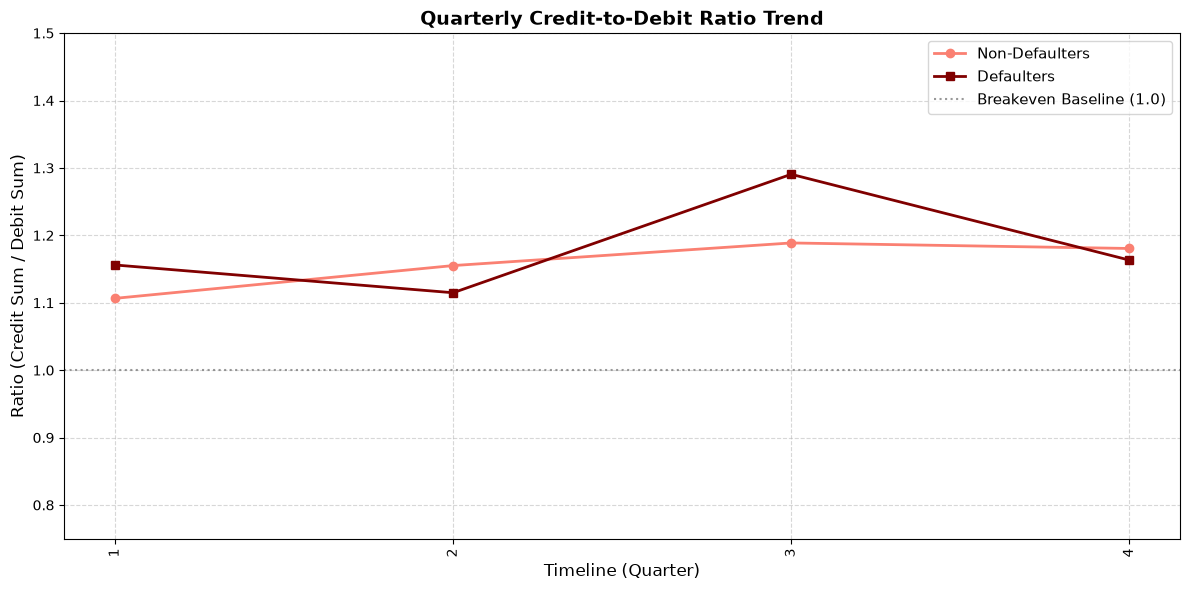

In [73]:
# Credit to debit ratio quarterly trend over time
dft["quarter"] = dft["date"].dt.quarter
quarterly_sums = (
    dft.groupby(["account_id", "quarter", "type"])["amount"]
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)
merged_timeline = pd.merge(quarterly_sums, dfl, on="account_id", how="inner")
group_timeline = merged_timeline.groupby(["quarter", "defaulter"])[
    ["Credit", "Debit"]
].sum()
group_timeline["credit_debit_ratio"] = (
    group_timeline["Credit"] / group_timeline["Debit"]
)
ratio_timeline = group_timeline["credit_debit_ratio"].unstack()
ratio_timeline.index = ratio_timeline.index.astype(str)
ratio_timeline[ratio_timeline > 2] = None
plt.figure(figsize=(12, 6))
plt.plot(
    ratio_timeline.index,
    ratio_timeline[0],
    marker="o",
    color="salmon",
    linewidth=2,
    label="Non-Defaulters",
)
plt.plot(
    ratio_timeline.index,
    ratio_timeline[1],
    marker="s",
    color="maroon",
    linewidth=2,
    label="Defaulters",
)
plt.axhline(
    y=1.0,
    color="gray",
    linestyle=":",
    alpha=0.8,
    label="Breakeven Baseline (1.0)",
)
plt.title(
    "Quarterly Credit-to-Debit Ratio Trend",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Timeline (Quarter)", fontsize=12)
plt.ylabel("Ratio (Credit Sum / Debit Sum)", fontsize=12)
plt.ylim(0.75, 1.5)
plt.xticks(rotation=90)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=11)
save_plot("credit_debit_ratio_trend.png")
plt.tight_layout()
plt.show()

> ##### *There is no reliable separation between defaulters and non-defaulters. At start, the difference is noticeable, but around 1994, Q3the difference starts to fade away. Conclusion  is that this metric is not useful/significant enough to flag defaulters.*

In [74]:
# Generate a new DataFrame merging the previous two to check for low balance just before installment date
loan_months_list = []
for _, row in dfl.iterrows():
    # Create a range of monthly periods from the loan's start to its end date
    months = pd.date_range(
        start=row['start_date'], end=row['end_date'], freq='MS'
    ).to_period('M')
    for m in months:
        loan_months_list.append(
            {
                'account_id': row['account_id'],
                'loan_id': row['loan_id'],
                'month': str(m),
                'installment': row['installment'],
                'defaulter': row['defaulter'],
            }
        )


loan_timeline_df = pd.DataFrame(loan_months_list)
dft['month'] = dft['date'].dt.to_period('M').astype(str)
df_sorted = dft.sort_values(by=['account_id', 'date', 'trans_id'])

monthly_closing_balances = (
    df_sorted.groupby(['account_id', 'month'])['balance'].last().reset_index()
)

tracking_df = pd.merge(
    loan_timeline_df,
    monthly_closing_balances,
    on=['account_id', 'month'],
    how='left',
)
tracking_df['balance'] = tracking_df.groupby('account_id')['balance'].ffill()
tracking_df['balance'] = tracking_df['balance'].fillna(0)

tracking_df['is_balance_lower_than_installment'] = (
    tracking_df['balance'] < tracking_df['installment']
).astype(int)
print(
    tracking_df[
        [
            'account_id',
            'loan_id',
            'month',
            'balance',
            'installment',
            'is_balance_lower_than_installment',
            'defaulter',
        ]
    ].head()
)
save_csv(tracking_df, 'low_balance.csv')

   account_id  loan_id    month  balance  installment  \
0        1787     5314  1993-08  33612.4         8033   
1        1787     5314  1993-09  30503.0         8033   
2        1787     5314  1993-10  29893.6         8033   
3        1787     5314  1993-11  25284.2         8033   
4        1787     5314  1993-12  24574.8         8033   

   is_balance_lower_than_installment  defaulter  
0                                  0          1  
1                                  0          1  
2                                  0          1  
3                                  0          1  
4                                  0          1  
low_balance.csv saved to: ../data/processed\low_balance.csv


> ##### *On manual inspection of the generated csv, there are only a few instances where the account balance is actually lower than the installment amount, and that too only when the balance is negative. Strongly shows that negative is the only balance condition affecting defaulters.*

loan_size_vs_initial_account_balance.png saved to: ../plots\loan_size_vs_initial_account_balance.png


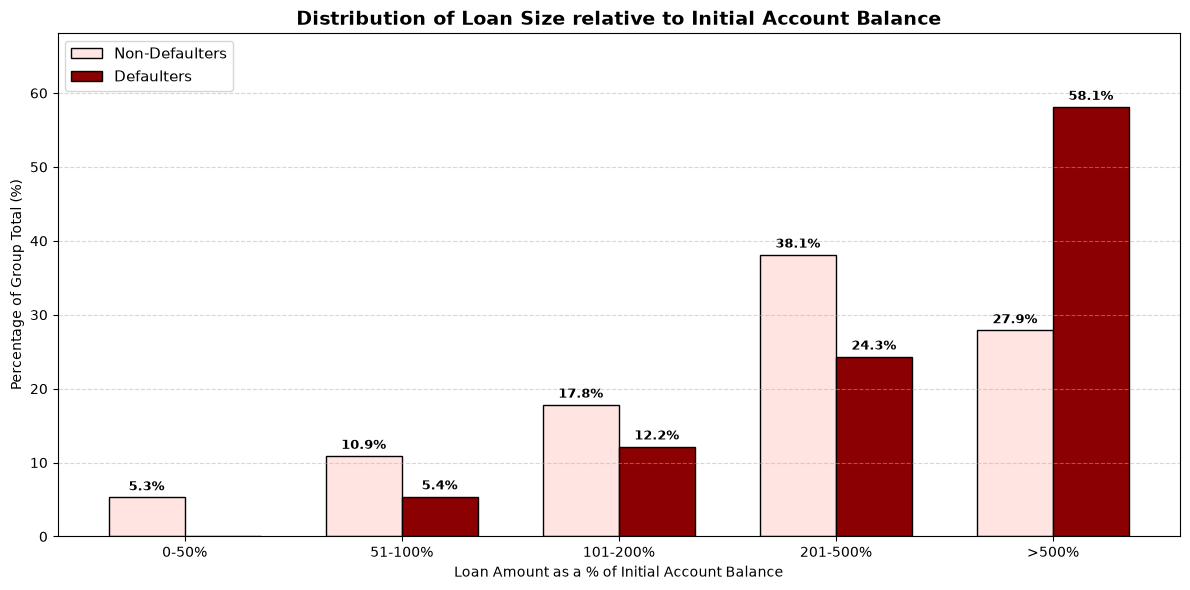

In [75]:
# Bivariate relation between loan size and the initial account balance
df_sorted = dft.sort_values(by=['account_id', 'date', 'trans_id'])
merged_init = pd.merge(
    df_sorted, dfl[['account_id', 'start_date']], on='account_id', how='inner'
)
pre_loan_txs = merged_init[merged_init['date'] < merged_init['start_date']]
pre_loan_balance = (
    pre_loan_txs.groupby('account_id')['balance'].last().reset_index()
)
pre_loan_balance.rename(
    columns={'balance': 'balance_at_start'}, inplace=True
)
loan_ratio_df = pd.merge(dfl, pre_loan_balance, on='account_id', how='inner')
loan_ratio_df = loan_ratio_df[loan_ratio_df['balance_at_start'] > 0].copy()
loan_ratio_df['loan_to_balance_pct'] = (loan_ratio_df['total_amount'] / loan_ratio_df['balance_at_start']) * 100

bins = [0, 50, 100, 200, 500, float('inf')]
labels = ['0-50%', '51-100%', '101-200%', '201-500%', '>500%']
loan_ratio_df['ratio_bin'] = pd.cut(
    loan_ratio_df['loan_to_balance_pct'], bins=bins, labels=labels
)
summary = (
    loan_ratio_df.groupby(['ratio_bin', 'defaulter'], observed=False)
    .size()
    .unstack(fill_value=0)
)
summary_pct = summary.div(summary.sum(axis=0), axis=1) * 100
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bar1 = ax.bar(
    x - width / 2,
    summary_pct[0],
    width,
    label='Non-Defaulters',
    color='mistyrose',
    edgecolor='black',
)
bar2 = ax.bar(
    x + width / 2,
    summary_pct[1],
    width,
    label='Defaulters',
    color='darkred',
    edgecolor='black',
)
for bar in bar1 + bar2:
    height = bar.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontweight='bold',
            fontsize=9,
        )
ax.set_title(
    'Distribution of Loan Size relative to Initial Account Balance',
    fontsize=14,
    fontweight='bold',
)
ax.set_xlabel('Loan Amount as a % of Initial Account Balance')
ax.set_ylabel('Percentage of Group Total (%)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, summary_pct.max().max() + 10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(fontsize=11)
save_plot('loan_size_vs_initial_account_balance.png')
plt.tight_layout()
plt.show()

> ##### *Another valuable yet logical insight: People who take loans greater than 500% of their account balances are much more likely to default.*

new_loans_per_quarter.png saved to: ../plots\new_loans_per_quarter.png


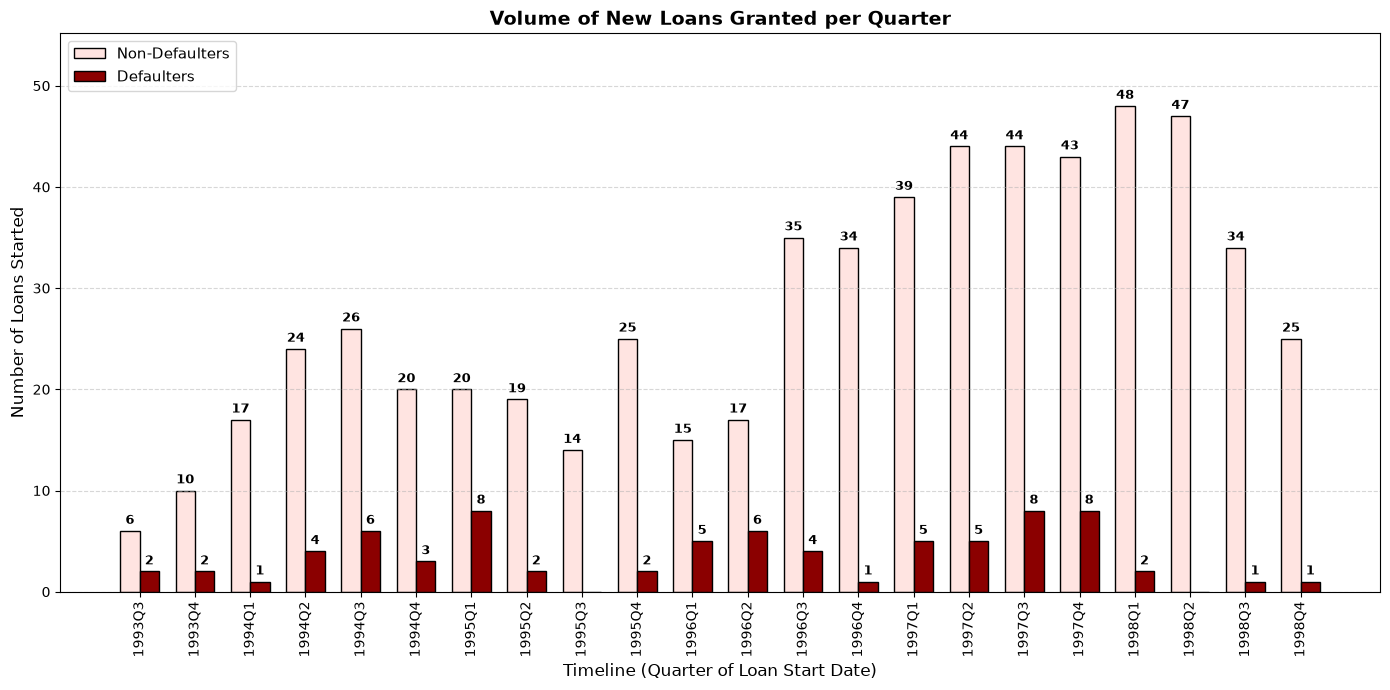

In [76]:
# Mapping the relation between the loans granted within a specific quarter and the default likelihood
dfl['start_quarter'] = dfl['start_date'].dt.to_period('Q').astype(str)
quarterly_counts = (
    dfl.groupby(['start_quarter', 'defaulter'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
quarters = quarterly_counts.index
non_defaulters_counts = quarterly_counts[0]
defaulters_counts = quarterly_counts[1]
x = np.arange(len(quarters))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
bar1 = ax.bar(
    x - width / 2,
    non_defaulters_counts,
    width,
    label='Non-Defaulters',
    color='mistyrose',
    edgecolor='black',
)
bar2 = ax.bar(
    x + width / 2,
    defaulters_counts,
    width,
    label='Defaulters',
    color='darkred',
    edgecolor='black',
)
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(
                f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontweight='bold',
                fontsize=9,
            )


add_labels(bar1)
add_labels(bar2)
ax.set_title(
    'Volume of New Loans Granted per Quarter', fontsize=14, fontweight='bold'
)
ax.set_xlabel('Timeline (Quarter of Loan Start Date)', fontsize=12)
ax.set_ylabel('Number of Loans Started', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(quarters, rotation=90)
ax.set_ylim(0, max(quarterly_counts.max()) * 1.15)  # Make room for text labels
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(fontsize=11, loc='upper left')
save_plot('new_loans_per_quarter.png')
plt.tight_layout()
plt.show()

> #####  *No useful insight here. The time for grant of a loan doesn't affect its default probability.*

default_rate_vs_quarter.png saved to: ../plots\default_rate_vs_quarter.png


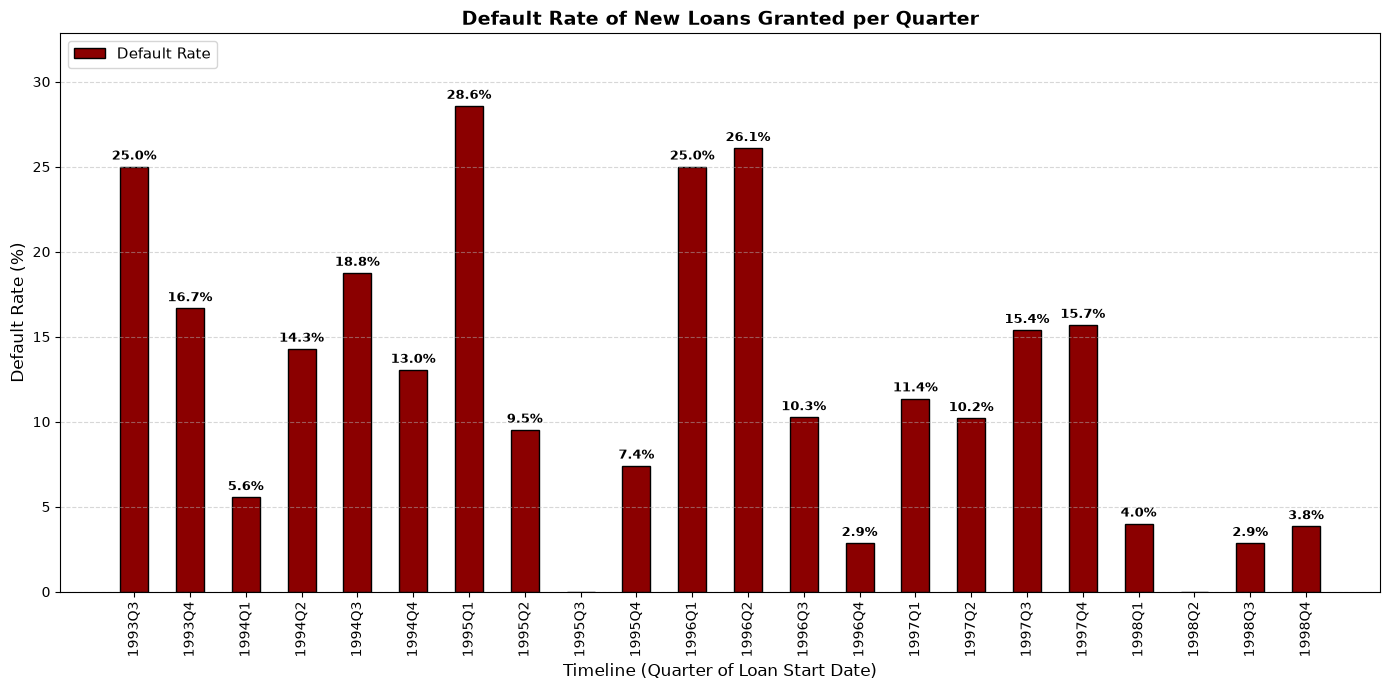

In [77]:
# Bivariate relation between the loans grant quarter and default rate
dfl["start_quarter"] = dfl["start_date"].dt.to_period("Q").astype(str)
quarterly_counts = (
    dfl.groupby(["start_quarter", "defaulter"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
quarters = quarterly_counts.index

quarterly_totals = quarterly_counts[0] + quarterly_counts[1]
quarterly_default_rates = (quarterly_counts[1] / quarterly_totals) * 100

x = np.arange(len(quarters))
width = 0.5

fig, ax = plt.subplots(figsize=(14, 7))
bar1 = ax.bar(
    x,
    quarterly_default_rates,
    width,
    label="Default Rate",
    color="darkred",
    edgecolor="black",
)


def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(
                f"{height:.1f}%",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontweight="bold",
                fontsize=9,
            )


add_labels(bar1)
ax.set_title(
    "Default Rate of New Loans Granted per Quarter",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Timeline (Quarter of Loan Start Date)", fontsize=12)
ax.set_ylabel("Default Rate (%)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(quarters, rotation=90)
ax.set_ylim(0, max(quarterly_default_rates) * 1.15)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(fontsize=11, loc="upper left")
save_plot('default_rate_vs_quarter.png')
plt.tight_layout()
plt.show()

> #####  *Again, No useful insight here. Confirmed, The time for grant of a loan doesn't affect its default probability.*

median_of_individual_mean_balances.png saved to: ../plots\median_of_individual_mean_balances.png


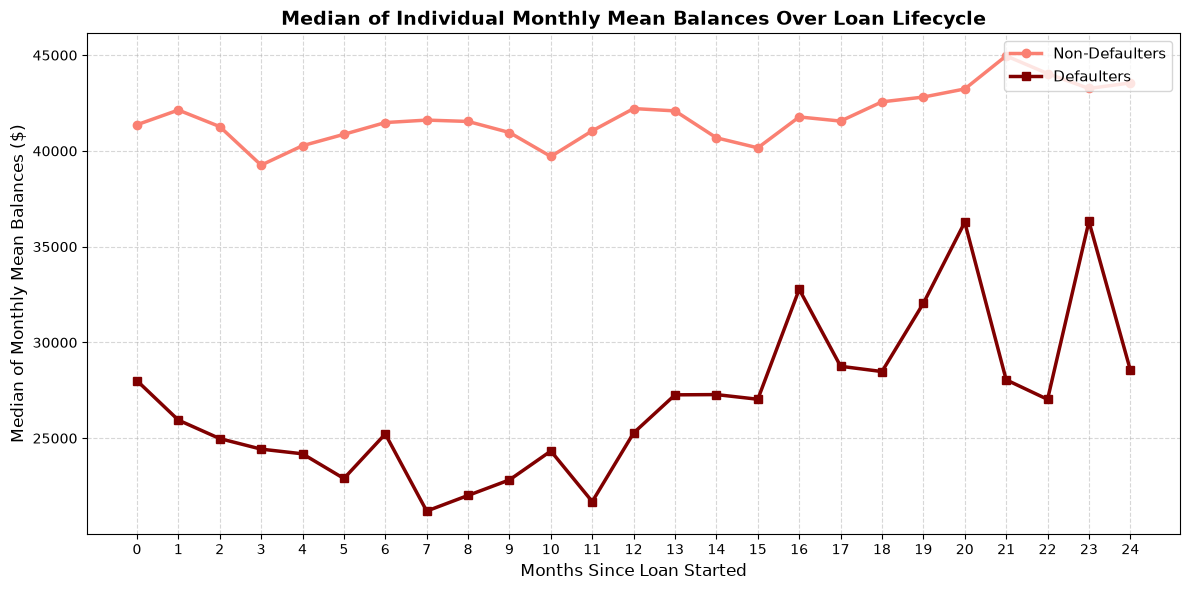

In [78]:
# Find median of individual monthly mean balances over entire loan lifecycle

dft['calendar_month'] = dft['date'].dt.to_period('M')
user_monthly_avg = (
    dft.groupby(['account_id', 'calendar_month'])['balance'].mean().reset_index()
)
merged_cohort = pd.merge(
    user_monthly_avg,
    dfl[['account_id', 'start_date', 'defaulter']],
    on='account_id',
    how='inner',
)

merged_cohort['loan_start_month'] = merged_cohort['start_date'].dt.to_period(
    'M'
)
merged_cohort['months_after_start'] = (
    merged_cohort['calendar_month'] - merged_cohort['loan_start_month']
).apply(lambda x: x.n)

cohort_data = merged_cohort[merged_cohort['months_after_start'] >= 0]
timeline_medians = (
    cohort_data.groupby(['months_after_start', 'defaulter'])['balance']
    .median()
    .unstack()
)
timeline_medians = timeline_medians.loc[:24]
plt.figure(figsize=(12, 6))
plt.plot(
    timeline_medians.index,
    timeline_medians[0],
    marker='o',
    color='salmon',
    linewidth=2.5,
    label='Non-Defaulters',
)
plt.plot(
    timeline_medians.index,
    timeline_medians[1],
    marker='s',
    color='maroon',
    linewidth=2.5,
    label='Defaulters',
)

plt.title(
    'Median of Individual Monthly Mean Balances Over Loan Lifecycle',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Months Since Loan Started', fontsize=12)
plt.ylabel('Median of Monthly Mean Balances ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(timeline_medians.index)  # Ensures every month milestone is marked
plt.legend(fontsize=11, loc='upper right')
save_plot('median_of_individual_mean_balances.png')
plt.tight_layout()
plt.show()

    > ##### *Directly implies that lower average monthly balance leads to a loan default. Visually observed threshold: $35000. Also, defaulters' balances oscillate, while non-defaulters' keep a visual consistency throughout.*

median_of_emi_balance_percentage.png saved to: ../plots\median_of_emi_balance_percentage.png


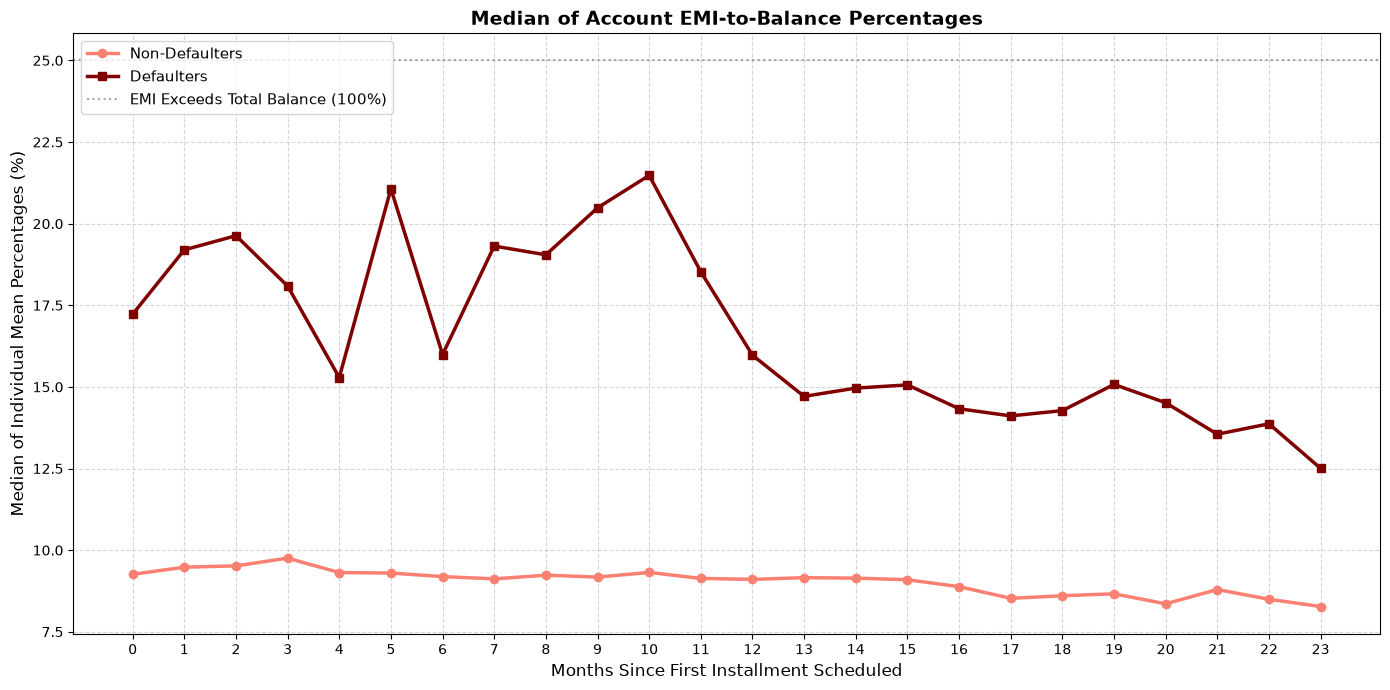

In [79]:
# Find median of EMI-to-balance percentages to study the relation between the EMI as a percentage of total account balance during a month and the likelihood of being default
timeline_records = []
for _, row in dfl.iterrows():
    base_installment_date = row['start_date'] + pd.Timedelta(days=30)

    for month_idx in range(24):
        calculated_due_date = base_installment_date + pd.DateOffset(
            months=month_idx
        )
        timeline_records.append(
            {
                'account_id': row['account_id'],
                'months_after_start': month_idx,
                'target_installment_date': calculated_due_date,
                'installment': row['installment'],
                'defaulter': row['defaulter'],
            }
        )
target_timeline_df = pd.DataFrame(timeline_records)
target_timeline_df = target_timeline_df.sort_values('target_installment_date')
df_sorted = dft.sort_values(by=['date', 'trans_id'])
merged_history = pd.merge_asof(
    target_timeline_df,
    df_sorted[['account_id', 'date', 'balance']],
    left_on='target_installment_date',
    right_on='date',
    by='account_id',
    direction='backward',
)
merged_history['balance'] = merged_history['balance'].fillna(0)
merged_history['balance_safe'] = merged_history['balance'].replace(0, 1)
merged_history['emi_percentage'] = (
    merged_history['installment'] / merged_history['balance_safe']
) * 100
account_monthly_means = (
    merged_history.groupby(
        ['months_after_start', 'account_id', 'defaulter'], observed=False
    )['emi_percentage']
    .mean()
    .reset_index()
)
final_timeline_medians = (
    account_monthly_means.groupby(['months_after_start', 'defaulter'])[
        'emi_percentage'
    ]
    .median()
    .unstack()
)
plt.figure(figsize=(14, 7))
plt.plot(
    final_timeline_medians.index,
    final_timeline_medians[0],
    marker='o',
    color='salmon',
    linewidth=2.5,
    label='Non-Defaulters',
)
plt.plot(
    final_timeline_medians.index,
    final_timeline_medians[1],
    marker='s',
    color='maroon',
    linewidth=2.5,
    label='Defaulters',
)
plt.axhline(
    y=25.0,
    color='gray',
    linestyle=':',
    alpha=0.7,
    label='EMI Exceeds Total Balance (100%)',
)
plt.title(
    'Median of Account EMI-to-Balance Percentages',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Months Since First Installment Scheduled', fontsize=12)
plt.ylabel('Median of Individual Mean Percentages (%)', fontsize=12)
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper left')
save_plot('median_of_emi_balance_percentage.png')
plt.tight_layout()
plt.show()

> ##### *Another very valuable insight. The accounts having their installments below 10% of their account balances just before the installment date are very likely to be non-defaulters. Getting that percentage in a range of 13-20% fairly increases the chance of being default. Also, the non-defaulters' ratio is very stable compared to the oscillations in defaulters' ratio. The downfall the the end signifies the balance accumulating without EMI payment. A clear flag.*

overdraft_vs_default_rate.png saved to: ../plots\overdraft_vs_default_rate.png


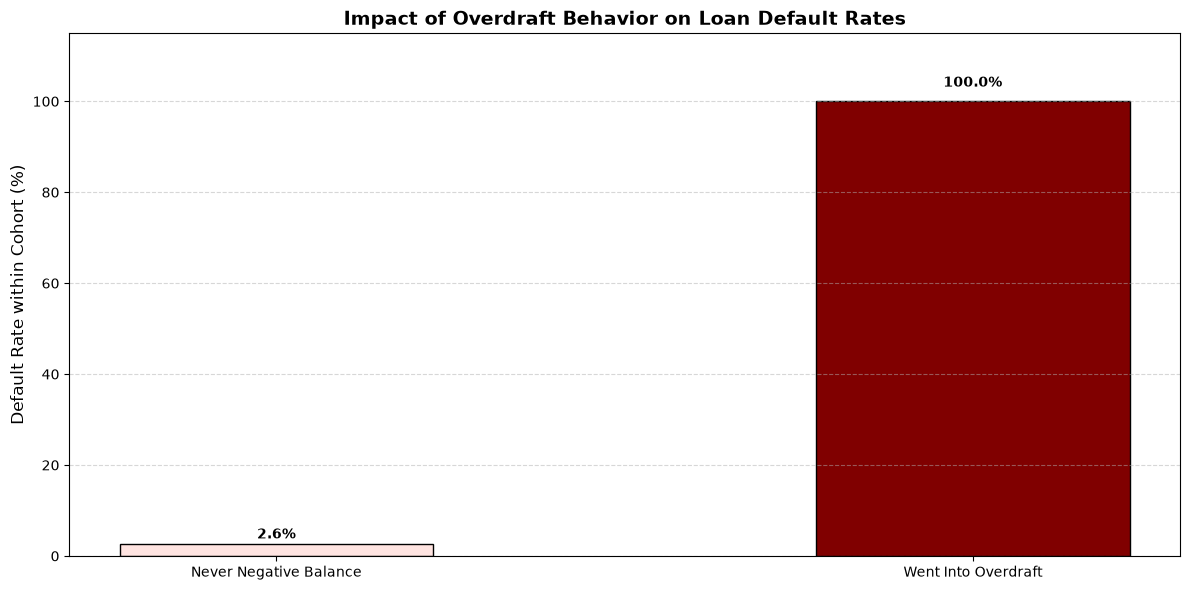

In [80]:
# Bivariate relation between overdraft and a default




merged_txs = pd.merge(
    dft,
    dfl[['account_id', 'start_date', 'end_date', 'defaulter']],
    on='account_id',
    how='inner',
)
active_loan_txs = merged_txs[
    (merged_txs['date'] >= merged_txs['start_date'])
    & (merged_txs['date'] <= merged_txs['end_date'])
]
overdraft_status = (
    active_loan_txs.groupby('account_id')['balance']
    .min()
    .apply(lambda min_bal: 1 if min_bal < 0 else 0)
    .reset_index(name='ever_overdrafted')
)
analysis_df = pd.merge(overdraft_status, dfl, on='account_id', how='inner')
default_rates = analysis_df.groupby('ever_overdrafted')['defaulter'].mean() * 100

rate_never_negative = default_rates[0]
rate_ever_overdrafted = default_rates[1]
risk_multiplier = rate_ever_overdrafted / rate_never_negative

plt.figure(figsize=(12, 6))
bars = plt.bar(
    ['Never Negative Balance', 'Went Into Overdraft'],
    [rate_never_negative, rate_ever_overdrafted],
    color=['mistyrose', 'maroon'],
    edgecolor='black',
    width=0.45,
)
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + (yval * 0.02) + 0.5,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold',
    )
plt.title(
    'Impact of Overdraft Behavior on Loan Default Rates',
    fontsize=14,
    fontweight='bold',
)
plt.ylabel('Default Rate within Cohort (%)', fontsize=12)
plt.ylim(0, max(default_rates) * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
save_plot('overdraft_vs_default_rate.png')
plt.tight_layout()
plt.show()

> ##### *A positive balance signals less probability of being a default, here quantified by 2.6%. Although 100% rate is not completely trustable, it still signals a flag whenever an account goes into overdraft.*

overdraft_vs_percentage_of_defaults.png saved to: ../plots\overdraft_vs_percentage_of_defaults.png


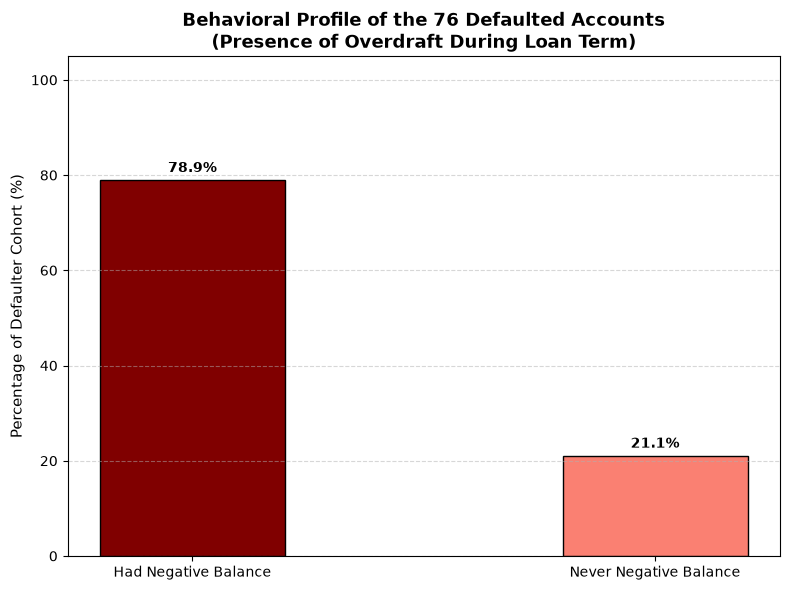

In [81]:
# Bivariate relation between overdraft and a default, but total defaulters as the denominator
merged_txs = pd.merge(
    dft,
    dfl[['account_id', 'start_date', 'end_date', 'defaulter']],
    on='account_id',
    how='inner',
)
active_loan_txs = merged_txs[
    (merged_txs['date'] >= merged_txs['start_date'])
    & (merged_txs['date'] <= merged_txs['end_date'])
]
min_balances = (
    active_loan_txs.groupby('account_id')['balance'].min().reset_index()
)
defaulters_df = dfl[dfl['defaulter'] == 1].copy()
total_defaulters = len(defaulters_df)
defaulters_with_balance = pd.merge(
    defaulters_df, min_balances, on='account_id', how='left'
)
defaulters_with_balance['balance'] = defaulters_with_balance[
    'balance'
].fillna(0)
had_neg_count = len(
    defaulters_with_balance[defaulters_with_balance['balance'] < 0]
)
stayed_pos_count = total_defaulters - had_neg_count
pct_had_neg = (had_neg_count / total_defaulters) * 100
pct_stayed_pos = (stayed_pos_count / total_defaulters) * 100
plt.figure(figsize=(8, 6))
bars = plt.bar(
    ['Had Negative Balance', 'Never Negative Balance'],
    [pct_had_neg, pct_stayed_pos],
    color=['maroon', 'salmon'],
    edgecolor='black',
    width=0.4,
)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold',
    )
plt.title(
    f'Behavioral Profile of the {total_defaulters} Defaulted Accounts\n(Presence of Overdraft During Loan Term)',
    fontsize=13,
    fontweight='bold',
)
plt.ylabel('Percentage of Defaulter Cohort (%)', fontsize=11)
plt.ylim(0, 105)
plt.grid(axis='y', linestyle='--', alpha=0.5)
save_plot('overdraft_vs_percentage_of_defaults.png')
plt.tight_layout()
plt.show()

> ##### *Clear insight. Overdraft accounts are far more likely to default than those who never had a negative account balance.*

volatility_score.png saved to: ../plots\volatility_score.png


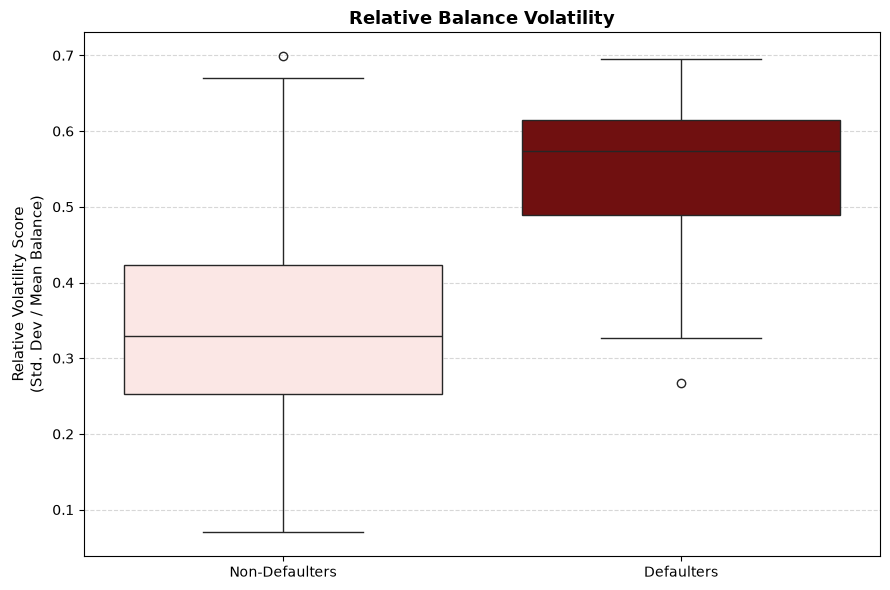

In [82]:
# Plot the volatility in accounts of defaulters vs non-defaulters
volatility_stats = (
    active_loan_txs.groupby('account_id')['balance']
    .agg(['std', 'mean'])
    .reset_index()
)

volatility_stats['relative_volatility'] = (
    volatility_stats['std'] / (volatility_stats['mean'] + 1e-6)
)

volatility_df = volatility_stats.merge(
    dfl[['account_id', 'defaulter']], on='account_id'
)

q_high = volatility_df['relative_volatility'].quantile(0.95)
filtered_volatility_df = volatility_df[
    volatility_df['relative_volatility'] < q_high
]
plt.figure(figsize=(9, 6))
sns.boxplot(
    data=filtered_volatility_df,
    x='defaulter',
    y='relative_volatility',
    palette={0: 'mistyrose', 1: 'maroon'},
    hue='defaulter',
    legend=False,
)
plt.title(
    'Relative Balance Volatility',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel('', fontsize=11)
plt.ylabel(
    'Relative Volatility Score\n(Std. Dev / Mean Balance)', fontsize=11
)
plt.xticks([0, 1], ['Non-Defaulters', 'Defaulters'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
save_plot('volatility_score.png')
plt.tight_layout()
plt.show()

> ##### *A very valuable insight. Accounts with higher flow volatility are much more likely to default. There is a significant difference between the volatility of defaulters' and non-defaulters' accounts.*

cv_comparison.png saved to: ../plots\cv_comparison.png


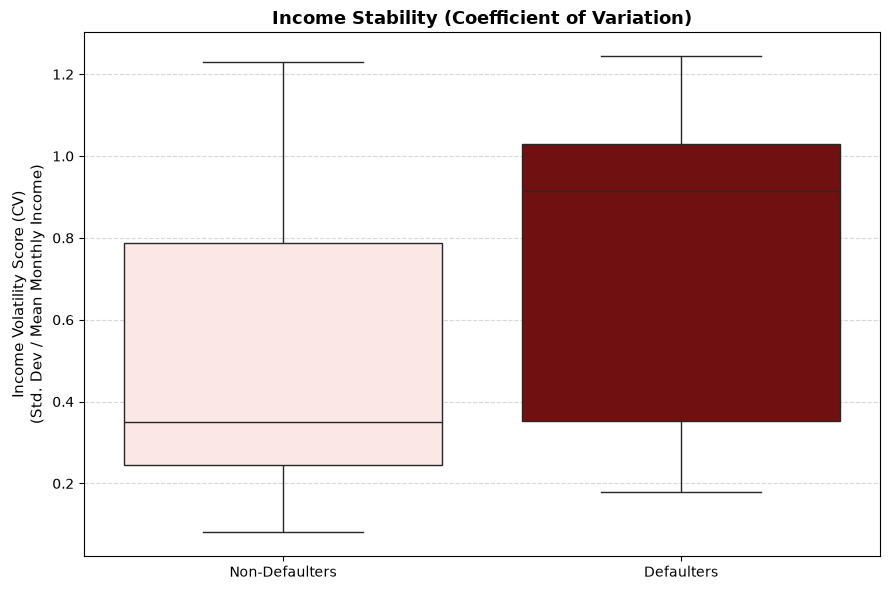

In [83]:
# Plot the coeficient of variation (CV) representing income stability for accounts of defaulters vs non-defaulters
monthly_credits = (
    active_loan_txs[active_loan_txs['type'] == 'Credit']
    .groupby(['account_id', active_loan_txs['date'].dt.to_period('M')])[
        'amount'
    ]
    .sum()
    .reset_index(name='monthly_income')
)

income_cv = (
    monthly_credits.groupby('account_id')['monthly_income']
    .agg(['mean', 'std'])
    .reset_index()
)
income_cv['cv'] = income_cv['std'] / (income_cv['mean'] + 1e-6)

income_cv = income_cv.merge(
    dfl[['account_id', 'defaulter']], on='account_id'
)

q_high = income_cv['cv'].quantile(0.95)
filtered_income_cv = income_cv[income_cv['cv'] < q_high]

plt.figure(figsize=(9, 6))
sns.boxplot(
    data=filtered_income_cv,
    x='defaulter',
    y='cv',
    palette={0: 'mistyrose', 1: 'maroon'},
    hue='defaulter',
    legend=False,
)

plt.title(
    'Income Stability (Coefficient of Variation)',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel('', fontsize=11)
plt.ylabel(
    'Income Volatility Score (CV)\n(Std. Dev / Mean Monthly Income)',
    fontsize=11,
)
plt.xticks([0, 1], ['Non-Defaulters', 'Defaulters'])

plt.grid(axis='y', linestyle='--', alpha=0.5)
save_plot('cv_comparison.png')
plt.tight_layout()
plt.show()

> ##### *Similar insights, but not as intense, irregular monthly deposits lead to somewhat higher default probability. Or, income irregularity is a contributing signal, but not a standalone separator.*

default_rate_vs_sanction.png saved to: ../plots\default_rate_vs_sanction.png


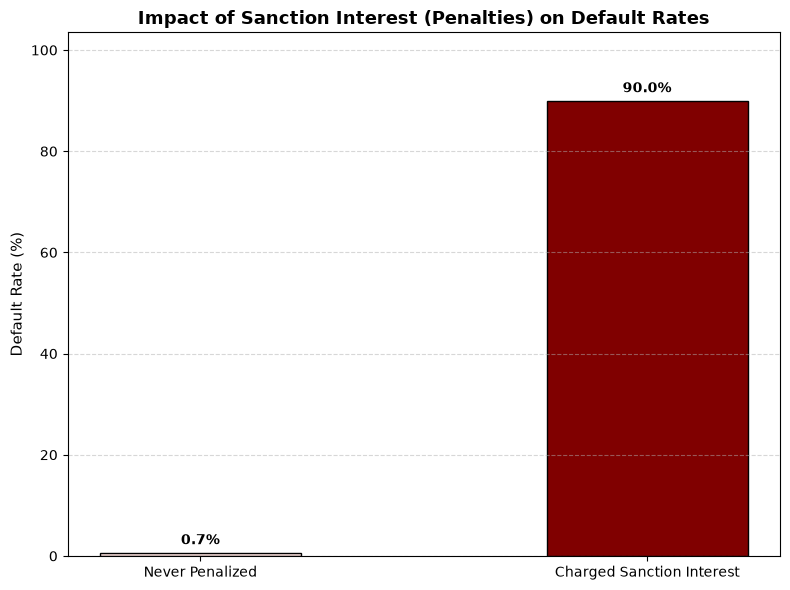

In [84]:
# Plot the impact of sanction on default rate
sanction_flag = (
    dft[dft['k_symbol'] == 'Sanction Interest']
    .groupby('account_id')
    .size()
    .reset_index(name='sanction_count')
)
sanction_df = (
    dfl[['account_id', 'defaulter']]
    .merge(sanction_flag, on='account_id', how='left')
    .fillna(0)
)
sanction_df['has_sanction'] = (sanction_df['sanction_count'] > 0).astype(int)
default_rates = sanction_df.groupby('has_sanction')['defaulter'].mean() * 100

rate_no_sanction = default_rates.get(0, 0.0)
rate_has_sanction = default_rates.get(1, 0.0)
risk_multiplier = (
    rate_has_sanction / rate_no_sanction if rate_no_sanction > 0 else 0
)
plt.figure(figsize=(8, 6))
bars = plt.bar(
    ['Never Penalized', 'Charged Sanction Interest'],
    [rate_no_sanction, rate_has_sanction],
    color=['mistyrose', 'maroon'],
    edgecolor='black',
    width=0.45,
)
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 1,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold',
    )
plt.title(
    'Impact of Sanction Interest (Penalties) on Default Rates',
    fontsize=13,
    fontweight='bold',
)
plt.ylabel('Default Rate (%)', fontsize=11)
plt.ylim(0, max(default_rates) * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
save_plot('default_rate_vs_sanction.png')
plt.tight_layout()
plt.show()

> ##### *Strongest insight till now. A sanction almost always means a default.*

monthly_transaction_frequency_comparison.png saved to: ../plots\monthly_transaction_frequency_comparison.png


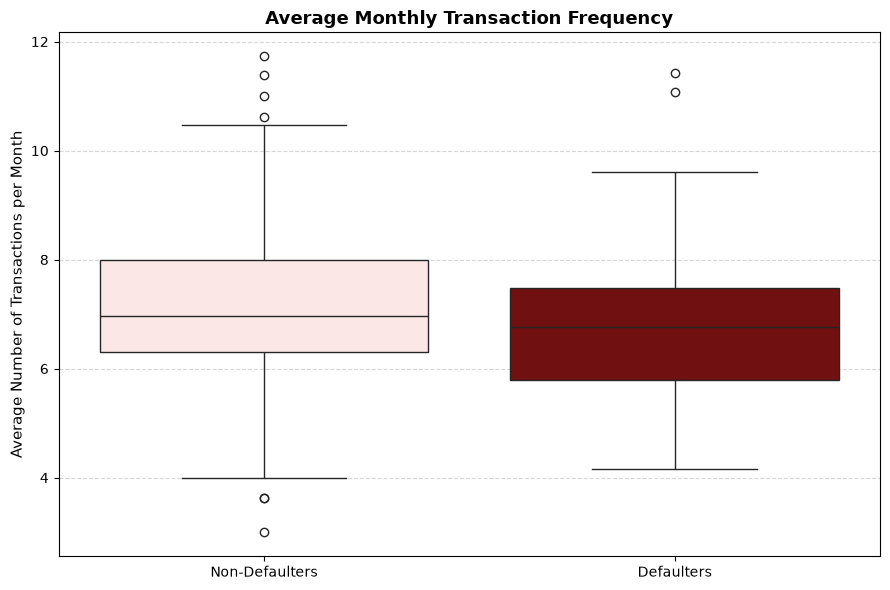

In [85]:
# Comparison of monthly transaction frequency of defaulters vs non-defaulters
tx_frequency = (
    active_loan_txs.groupby(
        ['account_id', active_loan_txs['date'].dt.to_period('M')]
    )
    .size()
    .reset_index(name='tx_count')
)

avg_frequency = (
    tx_frequency.groupby('account_id')['tx_count']
    .mean()
    .reset_index(name='avg_monthly_tx_count')
)

freq_df = avg_frequency.merge(
    dfl[['account_id', 'defaulter']], on='account_id'
)

plt.figure(figsize=(9, 6))
sns.boxplot(
    data=freq_df,
    x='defaulter',
    y='avg_monthly_tx_count',
    palette={0: 'mistyrose', 1: 'maroon'},
    hue='defaulter',
    legend=False,
)

plt.title(
    'Average Monthly Transaction Frequency',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel('', fontsize=11)
plt.ylabel('Average Number of Transactions per Month', fontsize=11)
plt.xticks([0, 1], ['Non-Defaulters', 'Defaulters'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
save_plot('monthly_transaction_frequency_comparison.png')
plt.tight_layout()
plt.show()

> ##### *Not the strongest factor, but transaction frequency carries much lower weight in deciding whether an account can default or not.*

credit_debit_ratio_trend.png saved to: ../plots\credit_debit_ratio_trend.png


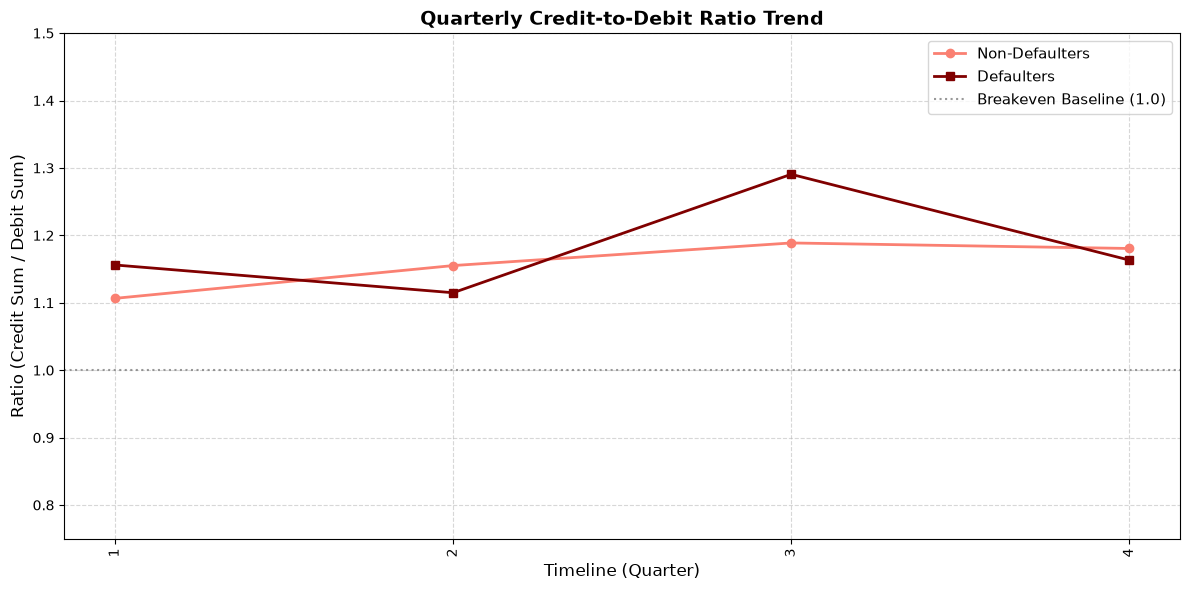

In [86]:
# Credit to debit ratio quarterly trend over time
dft["quarter"] = dft["date"].dt.quarter
quarterly_sums = (
    dft.groupby(["account_id", "quarter", "type"])["amount"]
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)
merged_timeline = pd.merge(quarterly_sums, dfl, on="account_id", how="inner")
group_timeline = merged_timeline.groupby(["quarter", "defaulter"])[
    ["Credit", "Debit"]
].sum()
group_timeline["credit_debit_ratio"] = (
    group_timeline["Credit"] / group_timeline["Debit"]
)
ratio_timeline = group_timeline["credit_debit_ratio"].unstack()
ratio_timeline.index = ratio_timeline.index.astype(str)
ratio_timeline[ratio_timeline > 2] = None
plt.figure(figsize=(12, 6))
plt.plot(
    ratio_timeline.index,
    ratio_timeline[0],
    marker="o",
    color="salmon",
    linewidth=2,
    label="Non-Defaulters",
)
plt.plot(
    ratio_timeline.index,
    ratio_timeline[1],
    marker="s",
    color="maroon",
    linewidth=2,
    label="Defaulters",
)
plt.axhline(
    y=1.0,
    color="gray",
    linestyle=":",
    alpha=0.8,
    label="Breakeven Baseline (1.0)",
)
plt.title(
    "Quarterly Credit-to-Debit Ratio Trend",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Timeline (Quarter)", fontsize=12)
plt.ylabel("Ratio (Credit Sum / Debit Sum)", fontsize=12)
plt.ylim(0.75, 1.5)
plt.xticks(rotation=90)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=11)
save_plot("credit_debit_ratio_trend.png")
plt.tight_layout()
plt.show()

> ##### *There is no reliable separation between defaulters and non-defaulters. At start, the difference is noticeable, but around 1994, Q3the difference starts to fade away. Conclusion  is that this metric is not useful/significant enough to flag defaulters.*

In [87]:
# Generate a new DataFrame merging the previous two to check for low balance just before installment date
loan_months_list = []
for _, row in dfl.iterrows():
    # Create a range of monthly periods from the loan's start to its end date
    months = pd.date_range(
        start=row['start_date'], end=row['end_date'], freq='MS'
    ).to_period('M')
    for m in months:
        loan_months_list.append(
            {
                'account_id': row['account_id'],
                'loan_id': row['loan_id'],
                'month': str(m),
                'installment': row['installment'],
                'defaulter': row['defaulter'],
            }
        )


loan_timeline_df = pd.DataFrame(loan_months_list)
dft['month'] = dft['date'].dt.to_period('M').astype(str)
df_sorted = dft.sort_values(by=['account_id', 'date', 'trans_id'])

monthly_closing_balances = (
    df_sorted.groupby(['account_id', 'month'])['balance'].last().reset_index()
)

tracking_df = pd.merge(
    loan_timeline_df,
    monthly_closing_balances,
    on=['account_id', 'month'],
    how='left',
)
tracking_df['balance'] = tracking_df.groupby('account_id')['balance'].ffill()
tracking_df['balance'] = tracking_df['balance'].fillna(0)

tracking_df['is_balance_lower_than_installment'] = (
    tracking_df['balance'] < tracking_df['installment']
).astype(int)
print(
    tracking_df[
        [
            'account_id',
            'loan_id',
            'month',
            'balance',
            'installment',
            'is_balance_lower_than_installment',
            'defaulter',
        ]
    ].head()
)
save_csv(tracking_df, 'low_balance.csv')

   account_id  loan_id    month  balance  installment  \
0        1787     5314  1993-08  33612.4         8033   
1        1787     5314  1993-09  30503.0         8033   
2        1787     5314  1993-10  29893.6         8033   
3        1787     5314  1993-11  25284.2         8033   
4        1787     5314  1993-12  24574.8         8033   

   is_balance_lower_than_installment  defaulter  
0                                  0          1  
1                                  0          1  
2                                  0          1  
3                                  0          1  
4                                  0          1  
low_balance.csv saved to: ../data/processed\low_balance.csv


> ##### *On manual inspection of the generated csv, there are only a few instances where the account balance is actually lower than the installment amount, and that too only when the balance is negative. Strongly shows that negative is the only balance condition affecting defaulters.*

loan_size_vs_initial_account_balance.png saved to: ../plots\loan_size_vs_initial_account_balance.png


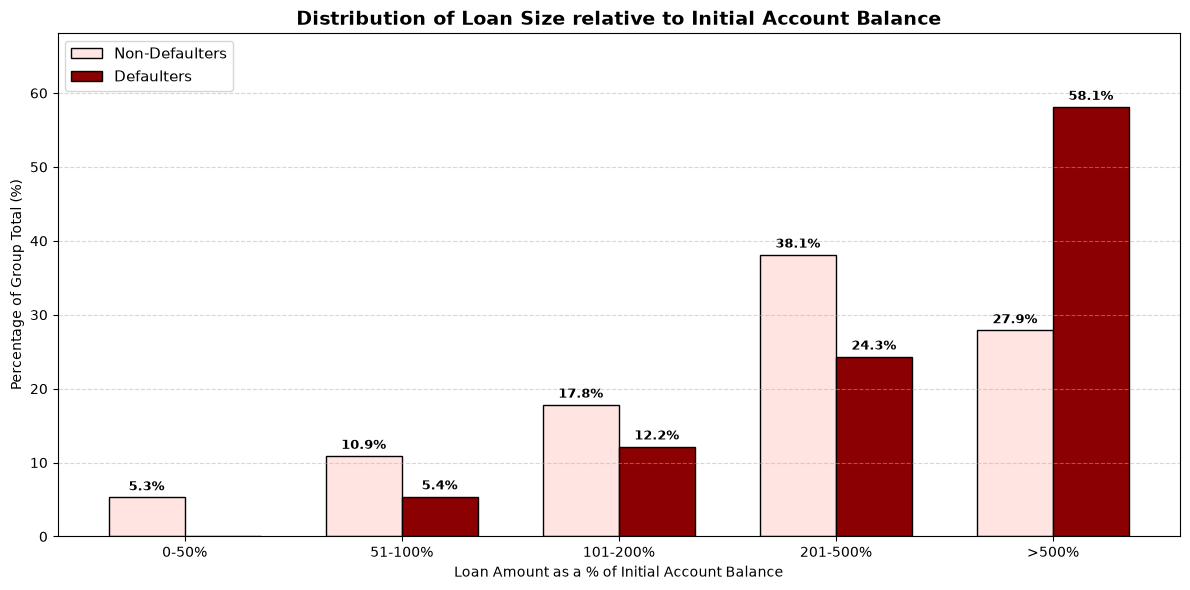

In [88]:
# Bivariate relation between loan size and the initial account balance
df_sorted = dft.sort_values(by=['account_id', 'date', 'trans_id'])
merged_init = pd.merge(
    df_sorted, dfl[['account_id', 'start_date']], on='account_id', how='inner'
)
pre_loan_txs = merged_init[merged_init['date'] < merged_init['start_date']]
pre_loan_balance = (
    pre_loan_txs.groupby('account_id')['balance'].last().reset_index()
)
pre_loan_balance.rename(
    columns={'balance': 'balance_at_start'}, inplace=True
)
loan_ratio_df = pd.merge(dfl, pre_loan_balance, on='account_id', how='inner')
loan_ratio_df = loan_ratio_df[loan_ratio_df['balance_at_start'] > 0].copy()
loan_ratio_df['loan_to_balance_pct'] = (loan_ratio_df['total_amount'] / loan_ratio_df['balance_at_start']) * 100

bins = [0, 50, 100, 200, 500, float('inf')]
labels = ['0-50%', '51-100%', '101-200%', '201-500%', '>500%']
loan_ratio_df['ratio_bin'] = pd.cut(
    loan_ratio_df['loan_to_balance_pct'], bins=bins, labels=labels
)
summary = (
    loan_ratio_df.groupby(['ratio_bin', 'defaulter'], observed=False)
    .size()
    .unstack(fill_value=0)
)
summary_pct = summary.div(summary.sum(axis=0), axis=1) * 100
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bar1 = ax.bar(
    x - width / 2,
    summary_pct[0],
    width,
    label='Non-Defaulters',
    color='mistyrose',
    edgecolor='black',
)
bar2 = ax.bar(
    x + width / 2,
    summary_pct[1],
    width,
    label='Defaulters',
    color='darkred',
    edgecolor='black',
)
for bar in bar1 + bar2:
    height = bar.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontweight='bold',
            fontsize=9,
        )
ax.set_title(
    'Distribution of Loan Size relative to Initial Account Balance',
    fontsize=14,
    fontweight='bold',
)
ax.set_xlabel('Loan Amount as a % of Initial Account Balance')
ax.set_ylabel('Percentage of Group Total (%)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, summary_pct.max().max() + 10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(fontsize=11)
save_plot('loan_size_vs_initial_account_balance.png')
plt.tight_layout()
plt.show()

> ##### *Another valuable yet logical insight: People who take loans greater than 500% of their account balances are much more likely to default.*

new_loans_per_quarter.png saved to: ../plots\new_loans_per_quarter.png


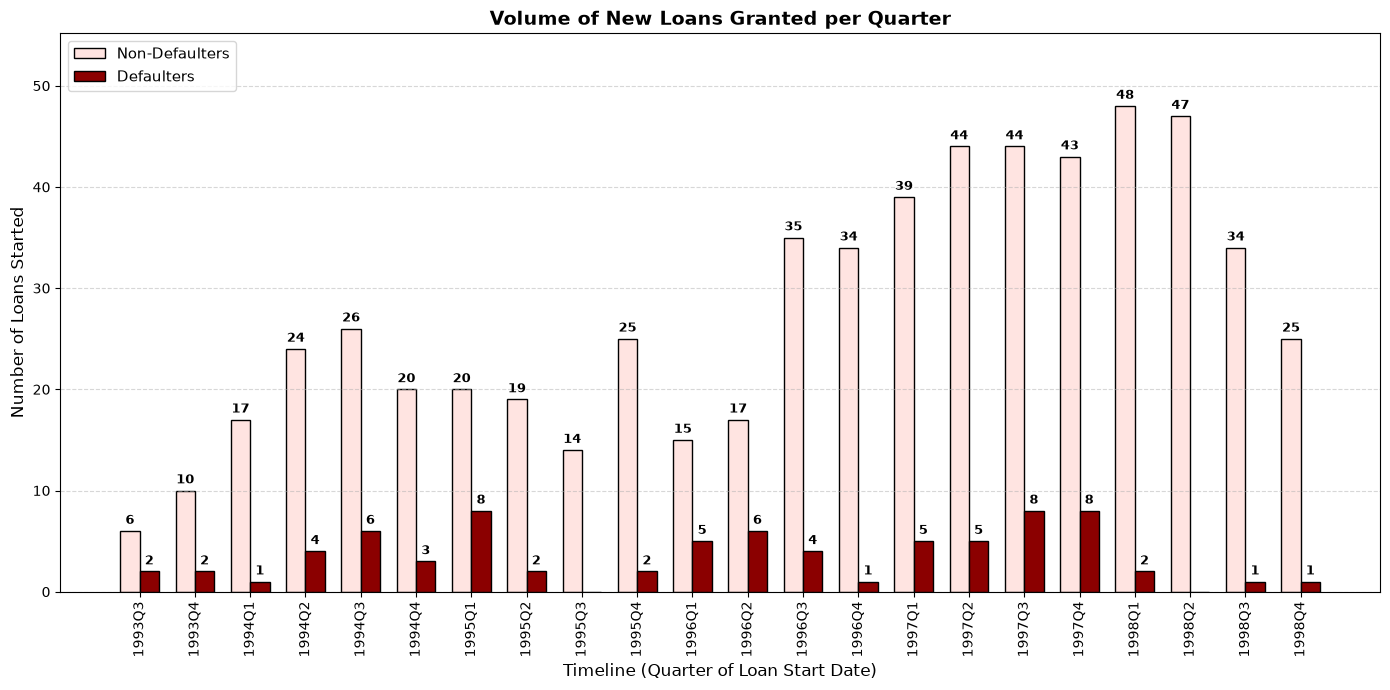

In [89]:
# Mapping the relation between the loans granted within a specific quarter and the default likelihood
dfl['start_quarter'] = dfl['start_date'].dt.to_period('Q').astype(str)
quarterly_counts = (
    dfl.groupby(['start_quarter', 'defaulter'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
quarters = quarterly_counts.index
non_defaulters_counts = quarterly_counts[0]
defaulters_counts = quarterly_counts[1]
x = np.arange(len(quarters))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
bar1 = ax.bar(
    x - width / 2,
    non_defaulters_counts,
    width,
    label='Non-Defaulters',
    color='mistyrose',
    edgecolor='black',
)
bar2 = ax.bar(
    x + width / 2,
    defaulters_counts,
    width,
    label='Defaulters',
    color='darkred',
    edgecolor='black',
)
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(
                f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontweight='bold',
                fontsize=9,
            )


add_labels(bar1)
add_labels(bar2)
ax.set_title(
    'Volume of New Loans Granted per Quarter', fontsize=14, fontweight='bold'
)
ax.set_xlabel('Timeline (Quarter of Loan Start Date)', fontsize=12)
ax.set_ylabel('Number of Loans Started', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(quarters, rotation=90)
ax.set_ylim(0, max(quarterly_counts.max()) * 1.15)  # Make room for text labels
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(fontsize=11, loc='upper left')
save_plot('new_loans_per_quarter.png')
plt.tight_layout()
plt.show()

> #####  *No useful insight here. The time for grant of a loan doesn't affect its default probability.*

default_rate_vs_quarter.png saved to: ../plots\default_rate_vs_quarter.png


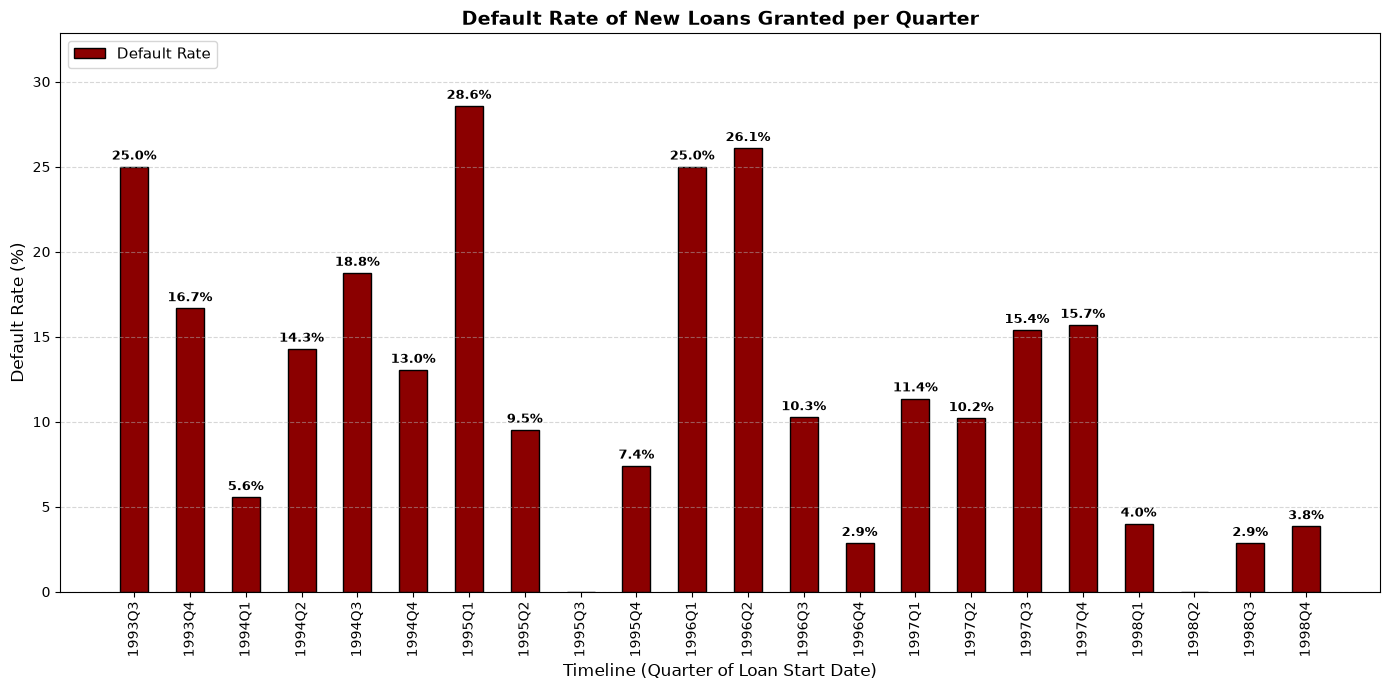

In [90]:
# Bivariate relation between the loans grant quarter and default rate
dfl["start_quarter"] = dfl["start_date"].dt.to_period("Q").astype(str)
quarterly_counts = (
    dfl.groupby(["start_quarter", "defaulter"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
quarters = quarterly_counts.index

quarterly_totals = quarterly_counts[0] + quarterly_counts[1]
quarterly_default_rates = (quarterly_counts[1] / quarterly_totals) * 100

x = np.arange(len(quarters))
width = 0.5

fig, ax = plt.subplots(figsize=(14, 7))
bar1 = ax.bar(
    x,
    quarterly_default_rates,
    width,
    label="Default Rate",
    color="darkred",
    edgecolor="black",
)


def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(
                f"{height:.1f}%",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontweight="bold",
                fontsize=9,
            )


add_labels(bar1)
ax.set_title(
    "Default Rate of New Loans Granted per Quarter",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Timeline (Quarter of Loan Start Date)", fontsize=12)
ax.set_ylabel("Default Rate (%)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(quarters, rotation=90)
ax.set_ylim(0, max(quarterly_default_rates) * 1.15)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(fontsize=11, loc="upper left")
save_plot('default_rate_vs_quarter.png')
plt.tight_layout()
plt.show()

> #####  *Again, No useful insight here. Confirmed, The time for grant of a loan doesn't affect its default probability.*

median_of_individual_mean_balances.png saved to: ../plots\median_of_individual_mean_balances.png


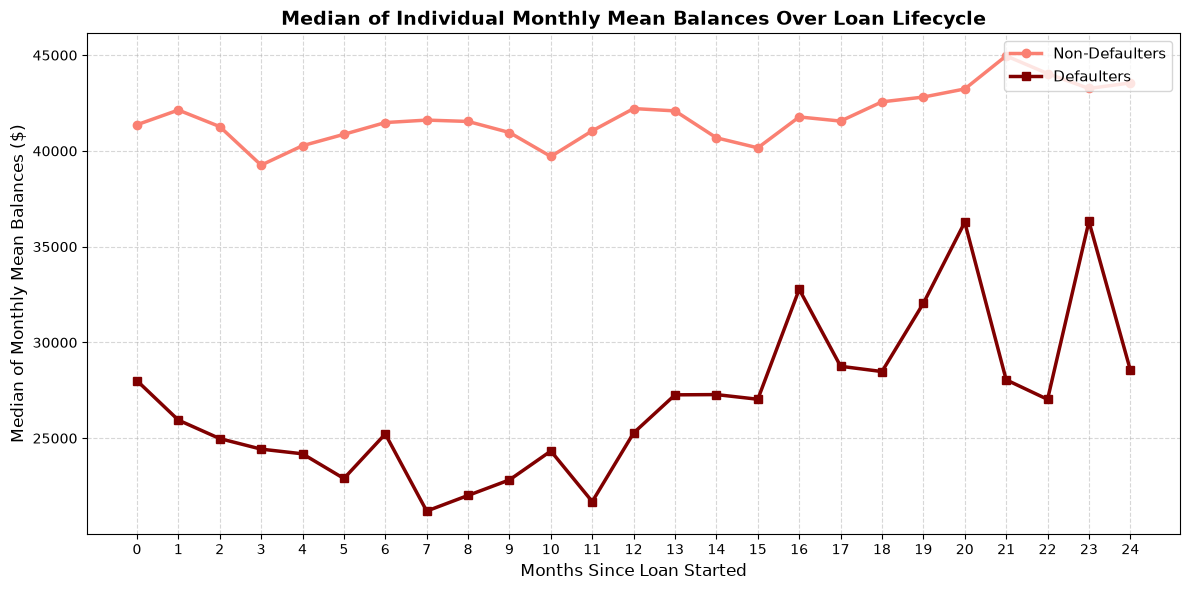

In [91]:
# Find median of individual monthly mean balances over entire loan lifecycle

dft['calendar_month'] = dft['date'].dt.to_period('M')
user_monthly_avg = (
    dft.groupby(['account_id', 'calendar_month'])['balance'].mean().reset_index()
)
merged_cohort = pd.merge(
    user_monthly_avg,
    dfl[['account_id', 'start_date', 'defaulter']],
    on='account_id',
    how='inner',
)

merged_cohort['loan_start_month'] = merged_cohort['start_date'].dt.to_period(
    'M'
)
merged_cohort['months_after_start'] = (
    merged_cohort['calendar_month'] - merged_cohort['loan_start_month']
).apply(lambda x: x.n)

cohort_data = merged_cohort[merged_cohort['months_after_start'] >= 0]
timeline_medians = (
    cohort_data.groupby(['months_after_start', 'defaulter'])['balance']
    .median()
    .unstack()
)
timeline_medians = timeline_medians.loc[:24]
plt.figure(figsize=(12, 6))
plt.plot(
    timeline_medians.index,
    timeline_medians[0],
    marker='o',
    color='salmon',
    linewidth=2.5,
    label='Non-Defaulters',
)
plt.plot(
    timeline_medians.index,
    timeline_medians[1],
    marker='s',
    color='maroon',
    linewidth=2.5,
    label='Defaulters',
)

plt.title(
    'Median of Individual Monthly Mean Balances Over Loan Lifecycle',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Months Since Loan Started', fontsize=12)
plt.ylabel('Median of Monthly Mean Balances ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(timeline_medians.index)  # Ensures every month milestone is marked
plt.legend(fontsize=11, loc='upper right')
save_plot('median_of_individual_mean_balances.png')
plt.tight_layout()
plt.show()

> ##### *Directly implies that lower average monthly balance leads to a loan default. Visually observed threshold: $35000. Also, defaulters' balances oscillate, while non-defaulters' keep a visual consistency throughout.*

median_of_emi_balance_percentage.png saved to: ../plots\median_of_emi_balance_percentage.png


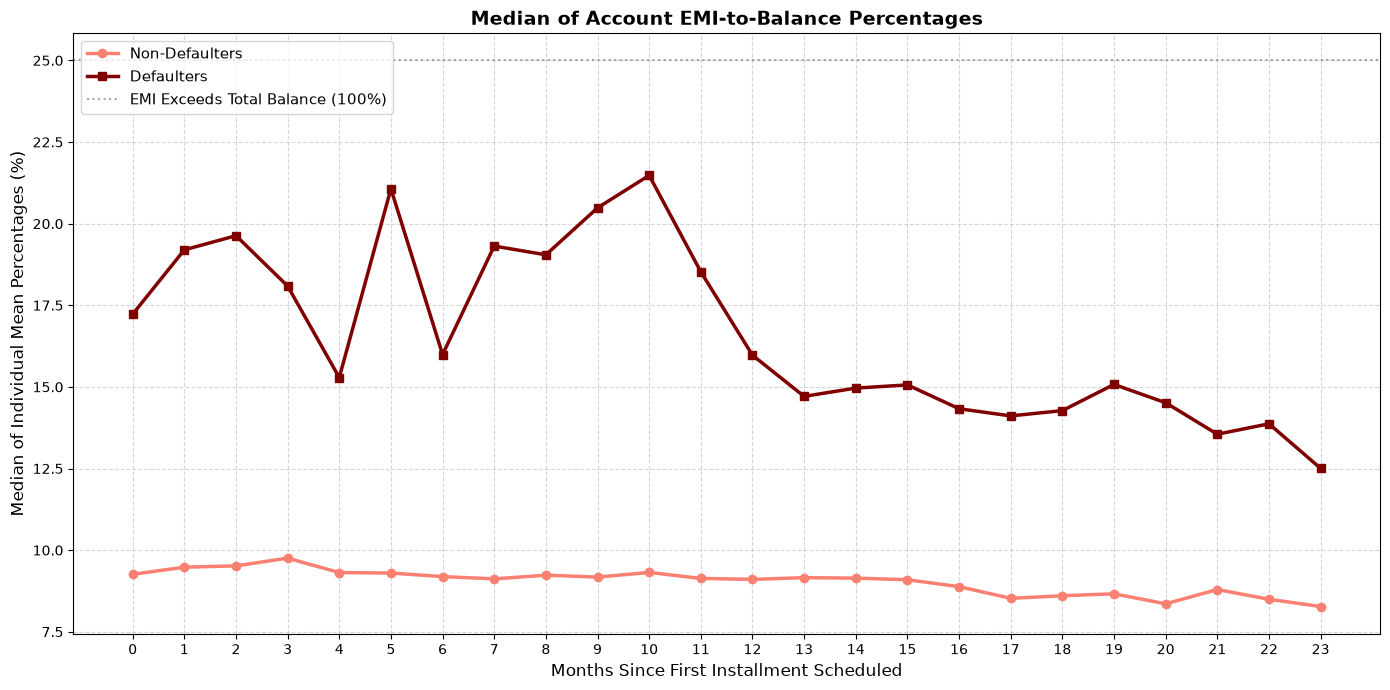

In [92]:
# Find median of EMI-to-balance percentages to study the relation between the EMI as a percentage of total account balance during a month and the likelihood of being default
timeline_records = []
for _, row in dfl.iterrows():
    base_installment_date = row['start_date'] + pd.Timedelta(days=30)

    for month_idx in range(24):
        calculated_due_date = base_installment_date + pd.DateOffset(
            months=month_idx
        )
        timeline_records.append(
            {
                'account_id': row['account_id'],
                'months_after_start': month_idx,
                'target_installment_date': calculated_due_date,
                'installment': row['installment'],
                'defaulter': row['defaulter'],
            }
        )
target_timeline_df = pd.DataFrame(timeline_records)
target_timeline_df = target_timeline_df.sort_values('target_installment_date')
df_sorted = dft.sort_values(by=['date', 'trans_id'])
merged_history = pd.merge_asof(
    target_timeline_df,
    df_sorted[['account_id', 'date', 'balance']],
    left_on='target_installment_date',
    right_on='date',
    by='account_id',
    direction='backward',
)
merged_history['balance'] = merged_history['balance'].fillna(0)
merged_history['balance_safe'] = merged_history['balance'].replace(0, 1)
merged_history['emi_percentage'] = (
    merged_history['installment'] / merged_history['balance_safe']
) * 100
account_monthly_means = (
    merged_history.groupby(
        ['months_after_start', 'account_id', 'defaulter'], observed=False
    )['emi_percentage']
    .mean()
    .reset_index()
)
final_timeline_medians = (
    account_monthly_means.groupby(['months_after_start', 'defaulter'])[
        'emi_percentage'
    ]
    .median()
    .unstack()
)
plt.figure(figsize=(14, 7))
plt.plot(
    final_timeline_medians.index,
    final_timeline_medians[0],
    marker='o',
    color='salmon',
    linewidth=2.5,
    label='Non-Defaulters',
)
plt.plot(
    final_timeline_medians.index,
    final_timeline_medians[1],
    marker='s',
    color='maroon',
    linewidth=2.5,
    label='Defaulters',
)
plt.axhline(
    y=25.0,
    color='gray',
    linestyle=':',
    alpha=0.7,
    label='EMI Exceeds Total Balance (100%)',
)
plt.title(
    'Median of Account EMI-to-Balance Percentages',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Months Since First Installment Scheduled', fontsize=12)
plt.ylabel('Median of Individual Mean Percentages (%)', fontsize=12)
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper left')
save_plot('median_of_emi_balance_percentage.png')
plt.tight_layout()
plt.show()

> ##### *Another very valuable insight. The accounts having their installments below 10% of their account balances just before the installment date are very likely to be non-defaulters. Getting that percentage in a range of 13-20% fairly increases the chance of being default. Also, the non-defaulters' ratio is very stable compared to the oscillations in defaulters' ratio. The downfall the the end signifies the balance accumulating without EMI payment. A clear flag.*

overdraft_vs_default_rate.png saved to: ../plots\overdraft_vs_default_rate.png


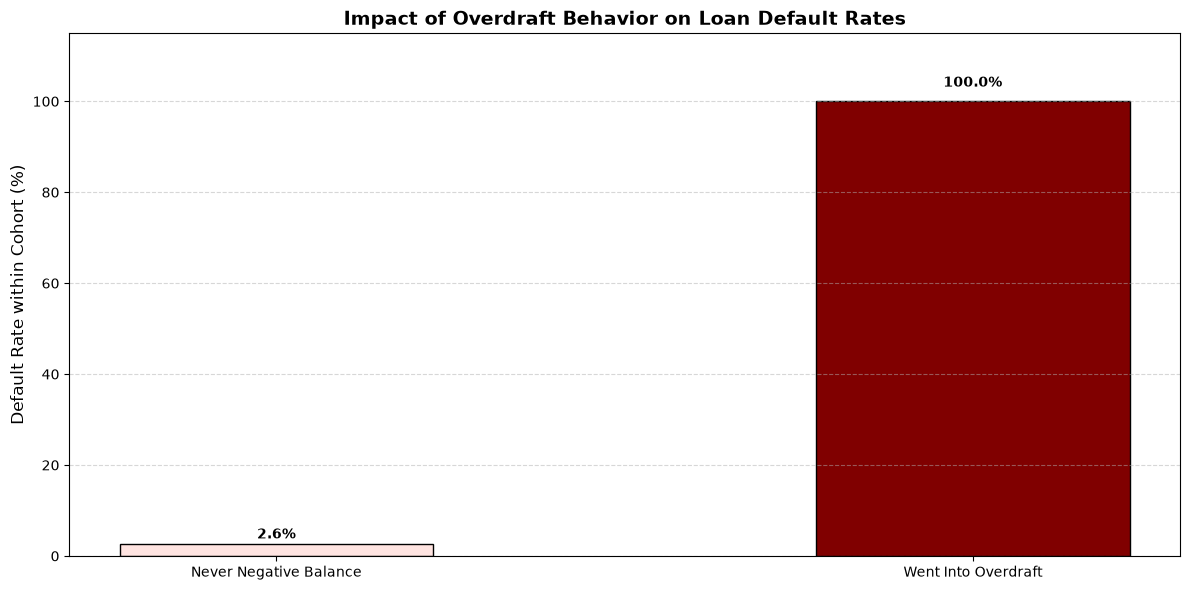

In [93]:
# Bivariate relation between overdraft and a default




merged_txs = pd.merge(
    dft,
    dfl[['account_id', 'start_date', 'end_date', 'defaulter']],
    on='account_id',
    how='inner',
)
active_loan_txs = merged_txs[
    (merged_txs['date'] >= merged_txs['start_date'])
    & (merged_txs['date'] <= merged_txs['end_date'])
]
overdraft_status = (
    active_loan_txs.groupby('account_id')['balance']
    .min()
    .apply(lambda min_bal: 1 if min_bal < 0 else 0)
    .reset_index(name='ever_overdrafted')
)
analysis_df = pd.merge(overdraft_status, dfl, on='account_id', how='inner')
default_rates = analysis_df.groupby('ever_overdrafted')['defaulter'].mean() * 100

rate_never_negative = default_rates[0]
rate_ever_overdrafted = default_rates[1]
risk_multiplier = rate_ever_overdrafted / rate_never_negative

plt.figure(figsize=(12, 6))
bars = plt.bar(
    ['Never Negative Balance', 'Went Into Overdraft'],
    [rate_never_negative, rate_ever_overdrafted],
    color=['mistyrose', 'maroon'],
    edgecolor='black',
    width=0.45,
)
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + (yval * 0.02) + 0.5,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold',
    )
plt.title(
    'Impact of Overdraft Behavior on Loan Default Rates',
    fontsize=14,
    fontweight='bold',
)
plt.ylabel('Default Rate within Cohort (%)', fontsize=12)
plt.ylim(0, max(default_rates) * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
save_plot('overdraft_vs_default_rate.png')
plt.tight_layout()
plt.show()

> ##### *A positive balance signals less probability of being a default, here quantified by 2.6%. Although 100% rate is not completely trustable, it still signals a flag whenever an account goes into overdraft.*

overdraft_vs_percentage_of_defaults.png saved to: ../plots\overdraft_vs_percentage_of_defaults.png


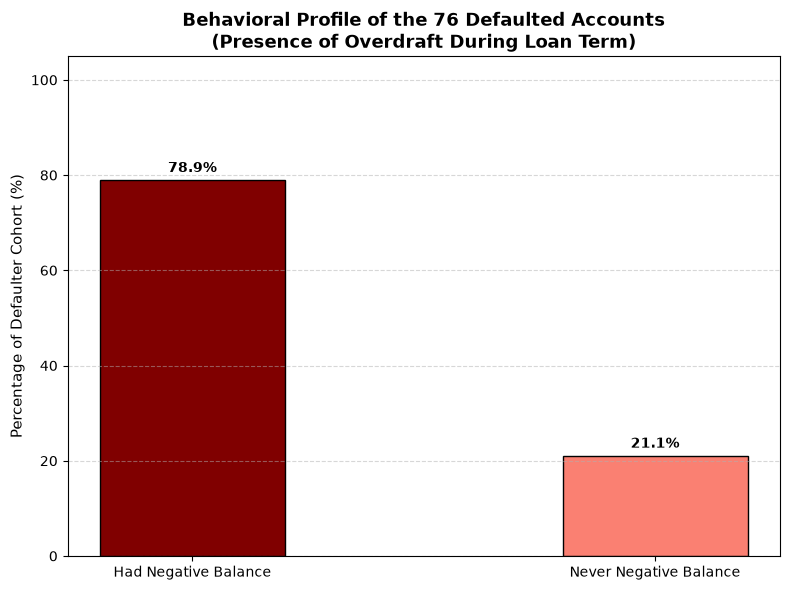

In [94]:
# Bivariate relation between overdraft and a default, but total defaulters as the denominator
merged_txs = pd.merge(
    dft,
    dfl[['account_id', 'start_date', 'end_date', 'defaulter']],
    on='account_id',
    how='inner',
)
active_loan_txs = merged_txs[
    (merged_txs['date'] >= merged_txs['start_date'])
    & (merged_txs['date'] <= merged_txs['end_date'])
]
min_balances = (
    active_loan_txs.groupby('account_id')['balance'].min().reset_index()
)
defaulters_df = dfl[dfl['defaulter'] == 1].copy()
total_defaulters = len(defaulters_df)
defaulters_with_balance = pd.merge(
    defaulters_df, min_balances, on='account_id', how='left'
)
defaulters_with_balance['balance'] = defaulters_with_balance[
    'balance'
].fillna(0)
had_neg_count = len(
    defaulters_with_balance[defaulters_with_balance['balance'] < 0]
)
stayed_pos_count = total_defaulters - had_neg_count
pct_had_neg = (had_neg_count / total_defaulters) * 100
pct_stayed_pos = (stayed_pos_count / total_defaulters) * 100
plt.figure(figsize=(8, 6))
bars = plt.bar(
    ['Had Negative Balance', 'Never Negative Balance'],
    [pct_had_neg, pct_stayed_pos],
    color=['maroon', 'salmon'],
    edgecolor='black',
    width=0.4,
)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold',
    )
plt.title(
    f'Behavioral Profile of the {total_defaulters} Defaulted Accounts\n(Presence of Overdraft During Loan Term)',
    fontsize=13,
    fontweight='bold',
)
plt.ylabel('Percentage of Defaulter Cohort (%)', fontsize=11)
plt.ylim(0, 105)
plt.grid(axis='y', linestyle='--', alpha=0.5)
save_plot('overdraft_vs_percentage_of_defaults.png')
plt.tight_layout()
plt.show()

> ##### *Clear insight. Overdraft accounts are far more likely to default than those who never had a negative account balance.*

volatility_score.png saved to: ../plots\volatility_score.png


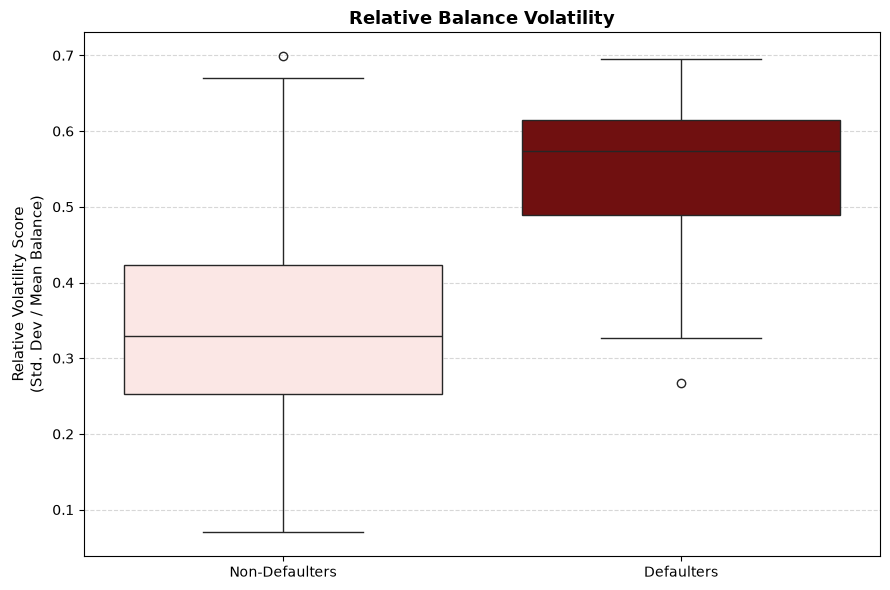

In [95]:
# Plot the volatility in accounts of defaulters vs non-defaulters
volatility_stats = (
    active_loan_txs.groupby('account_id')['balance']
    .agg(['std', 'mean'])
    .reset_index()
)

volatility_stats['relative_volatility'] = (
    volatility_stats['std'] / (volatility_stats['mean'] + 1e-6)
)

volatility_df = volatility_stats.merge(
    dfl[['account_id', 'defaulter']], on='account_id'
)

q_high = volatility_df['relative_volatility'].quantile(0.95)
filtered_volatility_df = volatility_df[
    volatility_df['relative_volatility'] < q_high
]
plt.figure(figsize=(9, 6))
sns.boxplot(
    data=filtered_volatility_df,
    x='defaulter',
    y='relative_volatility',
    palette={0: 'mistyrose', 1: 'maroon'},
    hue='defaulter',
    legend=False,
)
plt.title(
    'Relative Balance Volatility',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel('', fontsize=11)
plt.ylabel(
    'Relative Volatility Score\n(Std. Dev / Mean Balance)', fontsize=11
)
plt.xticks([0, 1], ['Non-Defaulters', 'Defaulters'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
save_plot('volatility_score.png')
plt.tight_layout()
plt.show()

> ##### *A very valuable insight. Accounts with higher flow volatility are much more likely to default. There is a significant difference between the volatility of defaulters' and non-defaulters' accounts.*

cv_comparison.png saved to: ../plots\cv_comparison.png


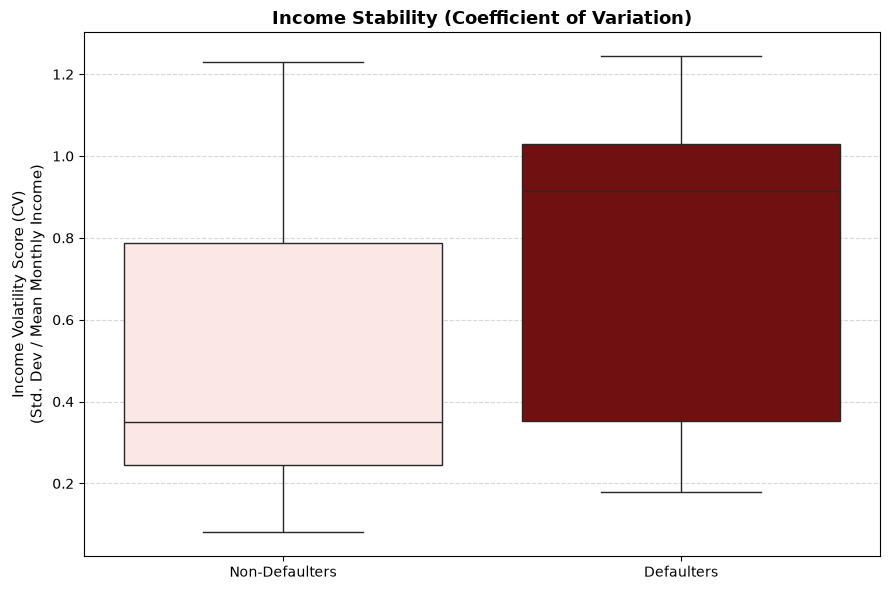

In [96]:
# Plot the coeficient of variation (CV) representing income stability for accounts of defaulters vs non-defaulters
monthly_credits = (
    active_loan_txs[active_loan_txs['type'] == 'Credit']
    .groupby(['account_id', active_loan_txs['date'].dt.to_period('M')])[
        'amount'
    ]
    .sum()
    .reset_index(name='monthly_income')
)

income_cv = (
    monthly_credits.groupby('account_id')['monthly_income']
    .agg(['mean', 'std'])
    .reset_index()
)
income_cv['cv'] = income_cv['std'] / (income_cv['mean'] + 1e-6)

income_cv = income_cv.merge(
    dfl[['account_id', 'defaulter']], on='account_id'
)

q_high = income_cv['cv'].quantile(0.95)
filtered_income_cv = income_cv[income_cv['cv'] < q_high]

plt.figure(figsize=(9, 6))
sns.boxplot(
    data=filtered_income_cv,
    x='defaulter',
    y='cv',
    palette={0: 'mistyrose', 1: 'maroon'},
    hue='defaulter',
    legend=False,
)

plt.title(
    'Income Stability (Coefficient of Variation)',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel('', fontsize=11)
plt.ylabel(
    'Income Volatility Score (CV)\n(Std. Dev / Mean Monthly Income)',
    fontsize=11,
)
plt.xticks([0, 1], ['Non-Defaulters', 'Defaulters'])

plt.grid(axis='y', linestyle='--', alpha=0.5)
save_plot('cv_comparison.png')
plt.tight_layout()
plt.show()

> ##### *Similar insights, but not as intense, irregular monthly deposits lead to somewhat higher default probability. Or, income irregularity is a contributing signal, but not a standalone separator.*

default_rate_vs_sanction.png saved to: ../plots\default_rate_vs_sanction.png


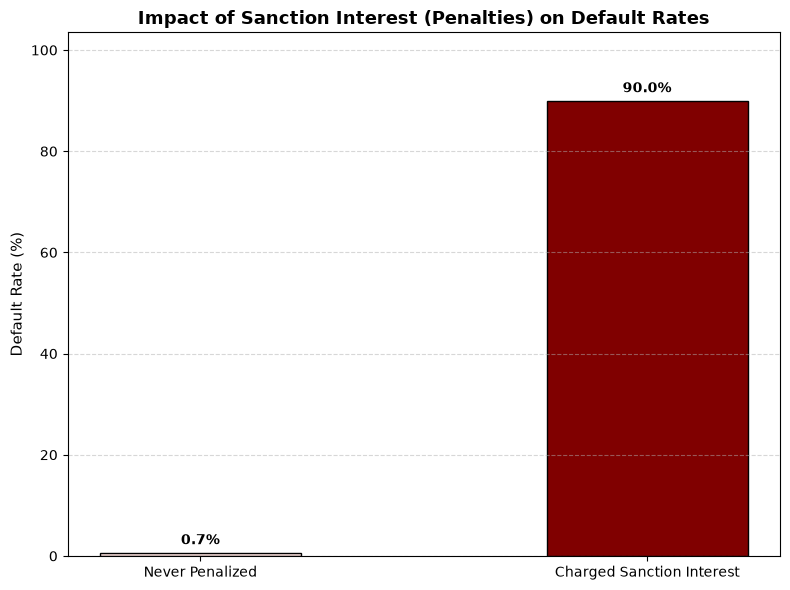

In [97]:
# Plot the impact of sanction on default rate
sanction_flag = (
    dft[dft['k_symbol'] == 'Sanction Interest']
    .groupby('account_id')
    .size()
    .reset_index(name='sanction_count')
)
sanction_df = (
    dfl[['account_id', 'defaulter']]
    .merge(sanction_flag, on='account_id', how='left')
    .fillna(0)
)
sanction_df['has_sanction'] = (sanction_df['sanction_count'] > 0).astype(int)
default_rates = sanction_df.groupby('has_sanction')['defaulter'].mean() * 100

rate_no_sanction = default_rates.get(0, 0.0)
rate_has_sanction = default_rates.get(1, 0.0)
risk_multiplier = (
    rate_has_sanction / rate_no_sanction if rate_no_sanction > 0 else 0
)
plt.figure(figsize=(8, 6))
bars = plt.bar(
    ['Never Penalized', 'Charged Sanction Interest'],
    [rate_no_sanction, rate_has_sanction],
    color=['mistyrose', 'maroon'],
    edgecolor='black',
    width=0.45,
)
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 1,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold',
    )
plt.title(
    'Impact of Sanction Interest (Penalties) on Default Rates',
    fontsize=13,
    fontweight='bold',
)
plt.ylabel('Default Rate (%)', fontsize=11)
plt.ylim(0, max(default_rates) * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
save_plot('default_rate_vs_sanction.png')
plt.tight_layout()
plt.show()

> ##### *Strongest insight till now. A sanction almost always means a default.*

monthly_transaction_frequency_comparison.png saved to: ../plots\monthly_transaction_frequency_comparison.png


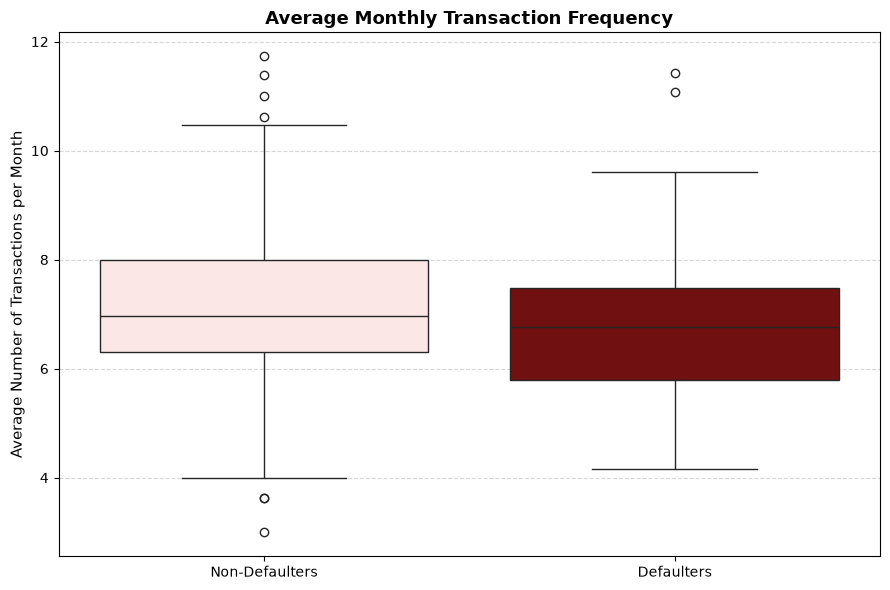

In [98]:
# Comparison of monthly transaction frequency of defaulters vs non-defaulters
tx_frequency = (
    active_loan_txs.groupby(
        ['account_id', active_loan_txs['date'].dt.to_period('M')]
    )
    .size()
    .reset_index(name='tx_count')
)

avg_frequency = (
    tx_frequency.groupby('account_id')['tx_count']
    .mean()
    .reset_index(name='avg_monthly_tx_count')
)

freq_df = avg_frequency.merge(
    dfl[['account_id', 'defaulter']], on='account_id'
)

plt.figure(figsize=(9, 6))
sns.boxplot(
    data=freq_df,
    x='defaulter',
    y='avg_monthly_tx_count',
    palette={0: 'mistyrose', 1: 'maroon'},
    hue='defaulter',
    legend=False,
)

plt.title(
    'Average Monthly Transaction Frequency',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel('', fontsize=11)
plt.ylabel('Average Number of Transactions per Month', fontsize=11)
plt.xticks([0, 1], ['Non-Defaulters', 'Defaulters'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
save_plot('monthly_transaction_frequency_comparison.png')
plt.tight_layout()
plt.show()

> ##### *Not the strongest factor, but transaction frequency carries much lower weight in deciding whether an account can default or not.*

credit_risk_correlation_matrix.png saved to: ../plots\credit_risk_correlation_matrix.png


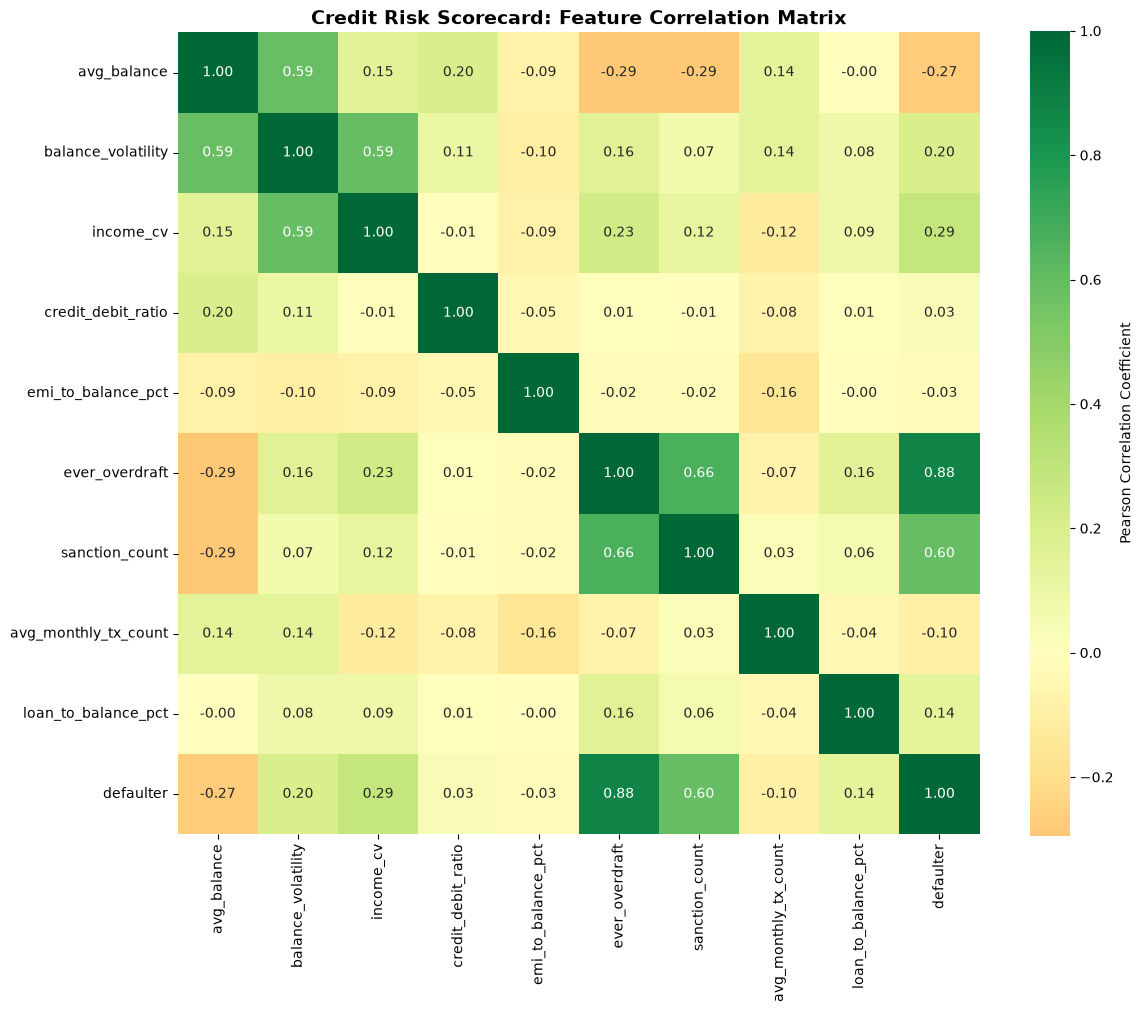

In [99]:
# The final confusion matrix relating all the attributes to defaulters
merged_txs = pd.merge(
    dft,
    dfl[["account_id", "start_date", "end_date", "defaulter", "installment"]],
    on="account_id",
    how="inner",
)
active_loan_txs = merged_txs[
    (merged_txs["date"] >= merged_txs["start_date"])
    & (merged_txs["date"] <= merged_txs["end_date"])
].copy()
active_loan_txs["month_year"] = active_loan_txs["date"].dt.to_period("M")
base_stats = (
    active_loan_txs.groupby("account_id")["balance"]
    .agg(avg_balance="mean", balance_volatility="std")
    .reset_index()
)
base_stats["balance_volatility"] = base_stats["balance_volatility"].fillna(0)
monthly_credits = (
    active_loan_txs[active_loan_txs["type"].str.lower() == "credit"]
    .groupby(["account_id", "month_year"])["amount"]
    .sum()
    .reset_index(name="monthly_income")
)
income_stats = (
    monthly_credits.groupby("account_id")["monthly_income"]
    .agg(["mean", "std"])
    .reset_index()
)
income_stats["income_cv"] = income_stats["std"] / (income_stats["mean"] + 1e-6)
income_stats["income_cv"] = income_stats["income_cv"].fillna(0)
tx_sums = (
    active_loan_txs.groupby(["account_id", "type"])["amount"]
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)
tx_sums.columns = tx_sums.columns.str.lower()
if "credit" not in tx_sums.columns:
    tx_sums["credit"] = 0
if "debit" not in tx_sums.columns:
    tx_sums["debit"] = 0
tx_sums["credit_debit_ratio"] = tx_sums["credit"] / (tx_sums["debit"] + 1e-6)
df_sorted = active_loan_txs.sort_values(by=["account_id", "date", "trans_id"])
df_sorted["balance_before_tx"] = df_sorted.groupby("account_id")[
    "balance"
].shift(1)
installment_txs = df_sorted[
    df_sorted["k_symbol"].str.upper().str.contains("UVER|LOAN", na=False)
].copy()
installment_txs["emi_pct"] = (
    installment_txs["installment"]
    / (installment_txs["balance_before_tx"].apply(lambda x: x if x > 0 else 1))
) * 100
emi_stats = (
    installment_txs.groupby("account_id")["emi_pct"]
    .median()
    .reset_index(name="emi_to_balance_pct")
)
overdraft_flag = (
    active_loan_txs.groupby("account_id")["balance"]
    .min()
    .apply(lambda min_bal: 1 if min_bal < 0 else 0)
    .reset_index(name="ever_overdraft")
)
sanction_flag = (
    active_loan_txs[
        active_loan_txs["k_symbol"].str.lower() == "sanction interest"
    ]
    .groupby("account_id")
    .size()
    .reset_index(name="sanction_count")
)
tx_freq = (
    active_loan_txs.groupby(["account_id", "month_year"])
    .size()
    .reset_index(name="tx_count")
)
freq_stats = (
    tx_freq.groupby("account_id")["tx_count"]
    .mean()
    .reset_index(name="avg_monthly_tx_count")
)
pre_loan_txs = merged_txs[merged_txs["date"] < merged_txs["start_date"]].copy()
pre_loan_balance = (
    pre_loan_txs.sort_values(by=["date", "trans_id"])
    .groupby("account_id")["balance"]
    .last()
    .reset_index(name="initial_balance")
)
loan_init = pd.merge(dfl, pre_loan_balance, on="account_id", how="inner")
loan_init["loan_to_balance_pct"] = (
    loan_init["total_amount"]
    / (loan_init["initial_balance"].apply(lambda x: x if x > 0 else 1))
) * 100
feature_matrix = dfl[["account_id", "defaulter"]].copy()
feature_matrix = feature_matrix.merge(
    base_stats[["account_id", "avg_balance", "balance_volatility"]],
    on="account_id",
    how="left",
)
feature_matrix = feature_matrix.merge(
    income_stats[["account_id", "income_cv"]], on="account_id", how="left"
)
feature_matrix = feature_matrix.merge(
    tx_sums[["account_id", "credit_debit_ratio"]], on="account_id", how="left"
)
feature_matrix = feature_matrix.merge(
    emi_stats[["account_id", "emi_to_balance_pct"]], on="account_id", how="left"
)
feature_matrix = feature_matrix.merge(
    overdraft_flag, on="account_id", how="left"
)
feature_matrix = feature_matrix.merge(
    sanction_flag, on="account_id", how="left"
)
feature_matrix = feature_matrix.merge(
    freq_stats[["account_id", "avg_monthly_tx_count"]],
    on="account_id",
    how="left",
)
feature_matrix = feature_matrix.merge(
    loan_init[["account_id", "loan_to_balance_pct"]],
    on="account_id",
    how="left",
)
feature_matrix = feature_matrix.fillna(0)
feature_cols = [
    "avg_balance",
    "balance_volatility",
    "income_cv",
    "credit_debit_ratio",
    "emi_to_balance_pct",
    "ever_overdraft",
    "sanction_count",
    "avg_monthly_tx_count",
    "loan_to_balance_pct",
    "defaulter",
]
corr = feature_matrix[feature_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    square=True,
    cbar_kws={"label": "Pearson Correlation Coefficient"},
)
plt.title(
    "Credit Risk Scorecard: Feature Correlation Matrix",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
save_plot("credit_risk_correlation_matrix.png")
plt.show()

> ##### *Sanctions and Overdrafts are the features strongly correlating to default, directly cncluded from this heatmap.*

In [100]:
dft.head()

,trans_id,account_id,date,type,operation,amount,balance,k_symbol,bank,account,month_year,quarter,month,calendar_month
0,695247,2378,1993-01-01,Credit,Cash Deposit,700.0,700.0,NaN,NaN,NaN,1993-01,1,1993-01,1993-01
1,171812,576,1993-01-01,Credit,Cash Deposit,900.0,900.0,NaN,NaN,NaN,1993-01,1,1993-01,1993-01
2,207264,704,1993-01-01,Credit,Cash Deposit,1000.0,1000.0,NaN,NaN,NaN,1993-01,1,1993-01,1993-01
3,1117247,3818,1993-01-01,Credit,Cash Deposit,600.0,600.0,NaN,NaN,NaN,1993-01,1,1993-01,1993-01
4,579373,1972,1993-01-02,Credit,Cash Deposit,400.0,400.0,NaN,NaN,NaN,1993-01,1,1993-01,1993-01


In [101]:
dfl.head()

,loan_id,account_id,start_date,total_amount,duration,installment,end_date,running,defaulter,start_quarter
0,5314,1787,1993-07-05,96396,12,8033,1994-07-05,1,1,1993Q3
1,5316,1801,1993-07-11,165960,36,4610,1996-07-11,1,0,1993Q3
2,6863,9188,1993-07-28,127080,60,2118,1998-07-28,1,0,1993Q3
3,5325,1843,1993-08-03,105804,36,2939,1996-08-03,1,0,1993Q3
4,7240,11013,1993-09-06,274740,60,4579,1998-09-06,1,0,1993Q3
